## Load libraries and files

In [36]:
library(dplyr)
library(Seurat)
library(patchwork)
library(stringr)
library(ggplot2)
library(EnhancedVolcano)
library(msigdbr)
library(fgsea)
library(gridExtra)
library(readxl)
library(grid)


dir1 = readline(prompt = "Please enter file directory to load LOG_NORM_NOVOALL_filt_final: ") # add .rds extension
LOG_NORM_NOVOALL_filt_final = readRDS(dir1)

Please enter file directory to load LOG_NORM_NOVOALL_filt_final:  ../data_files/LOG_NORM_NOVOALL_filt_final.rds


## Cell proportions by classification in each cluster

`summarise()` has grouped output by 'genotype'. You can override using the
`.groups` argument.


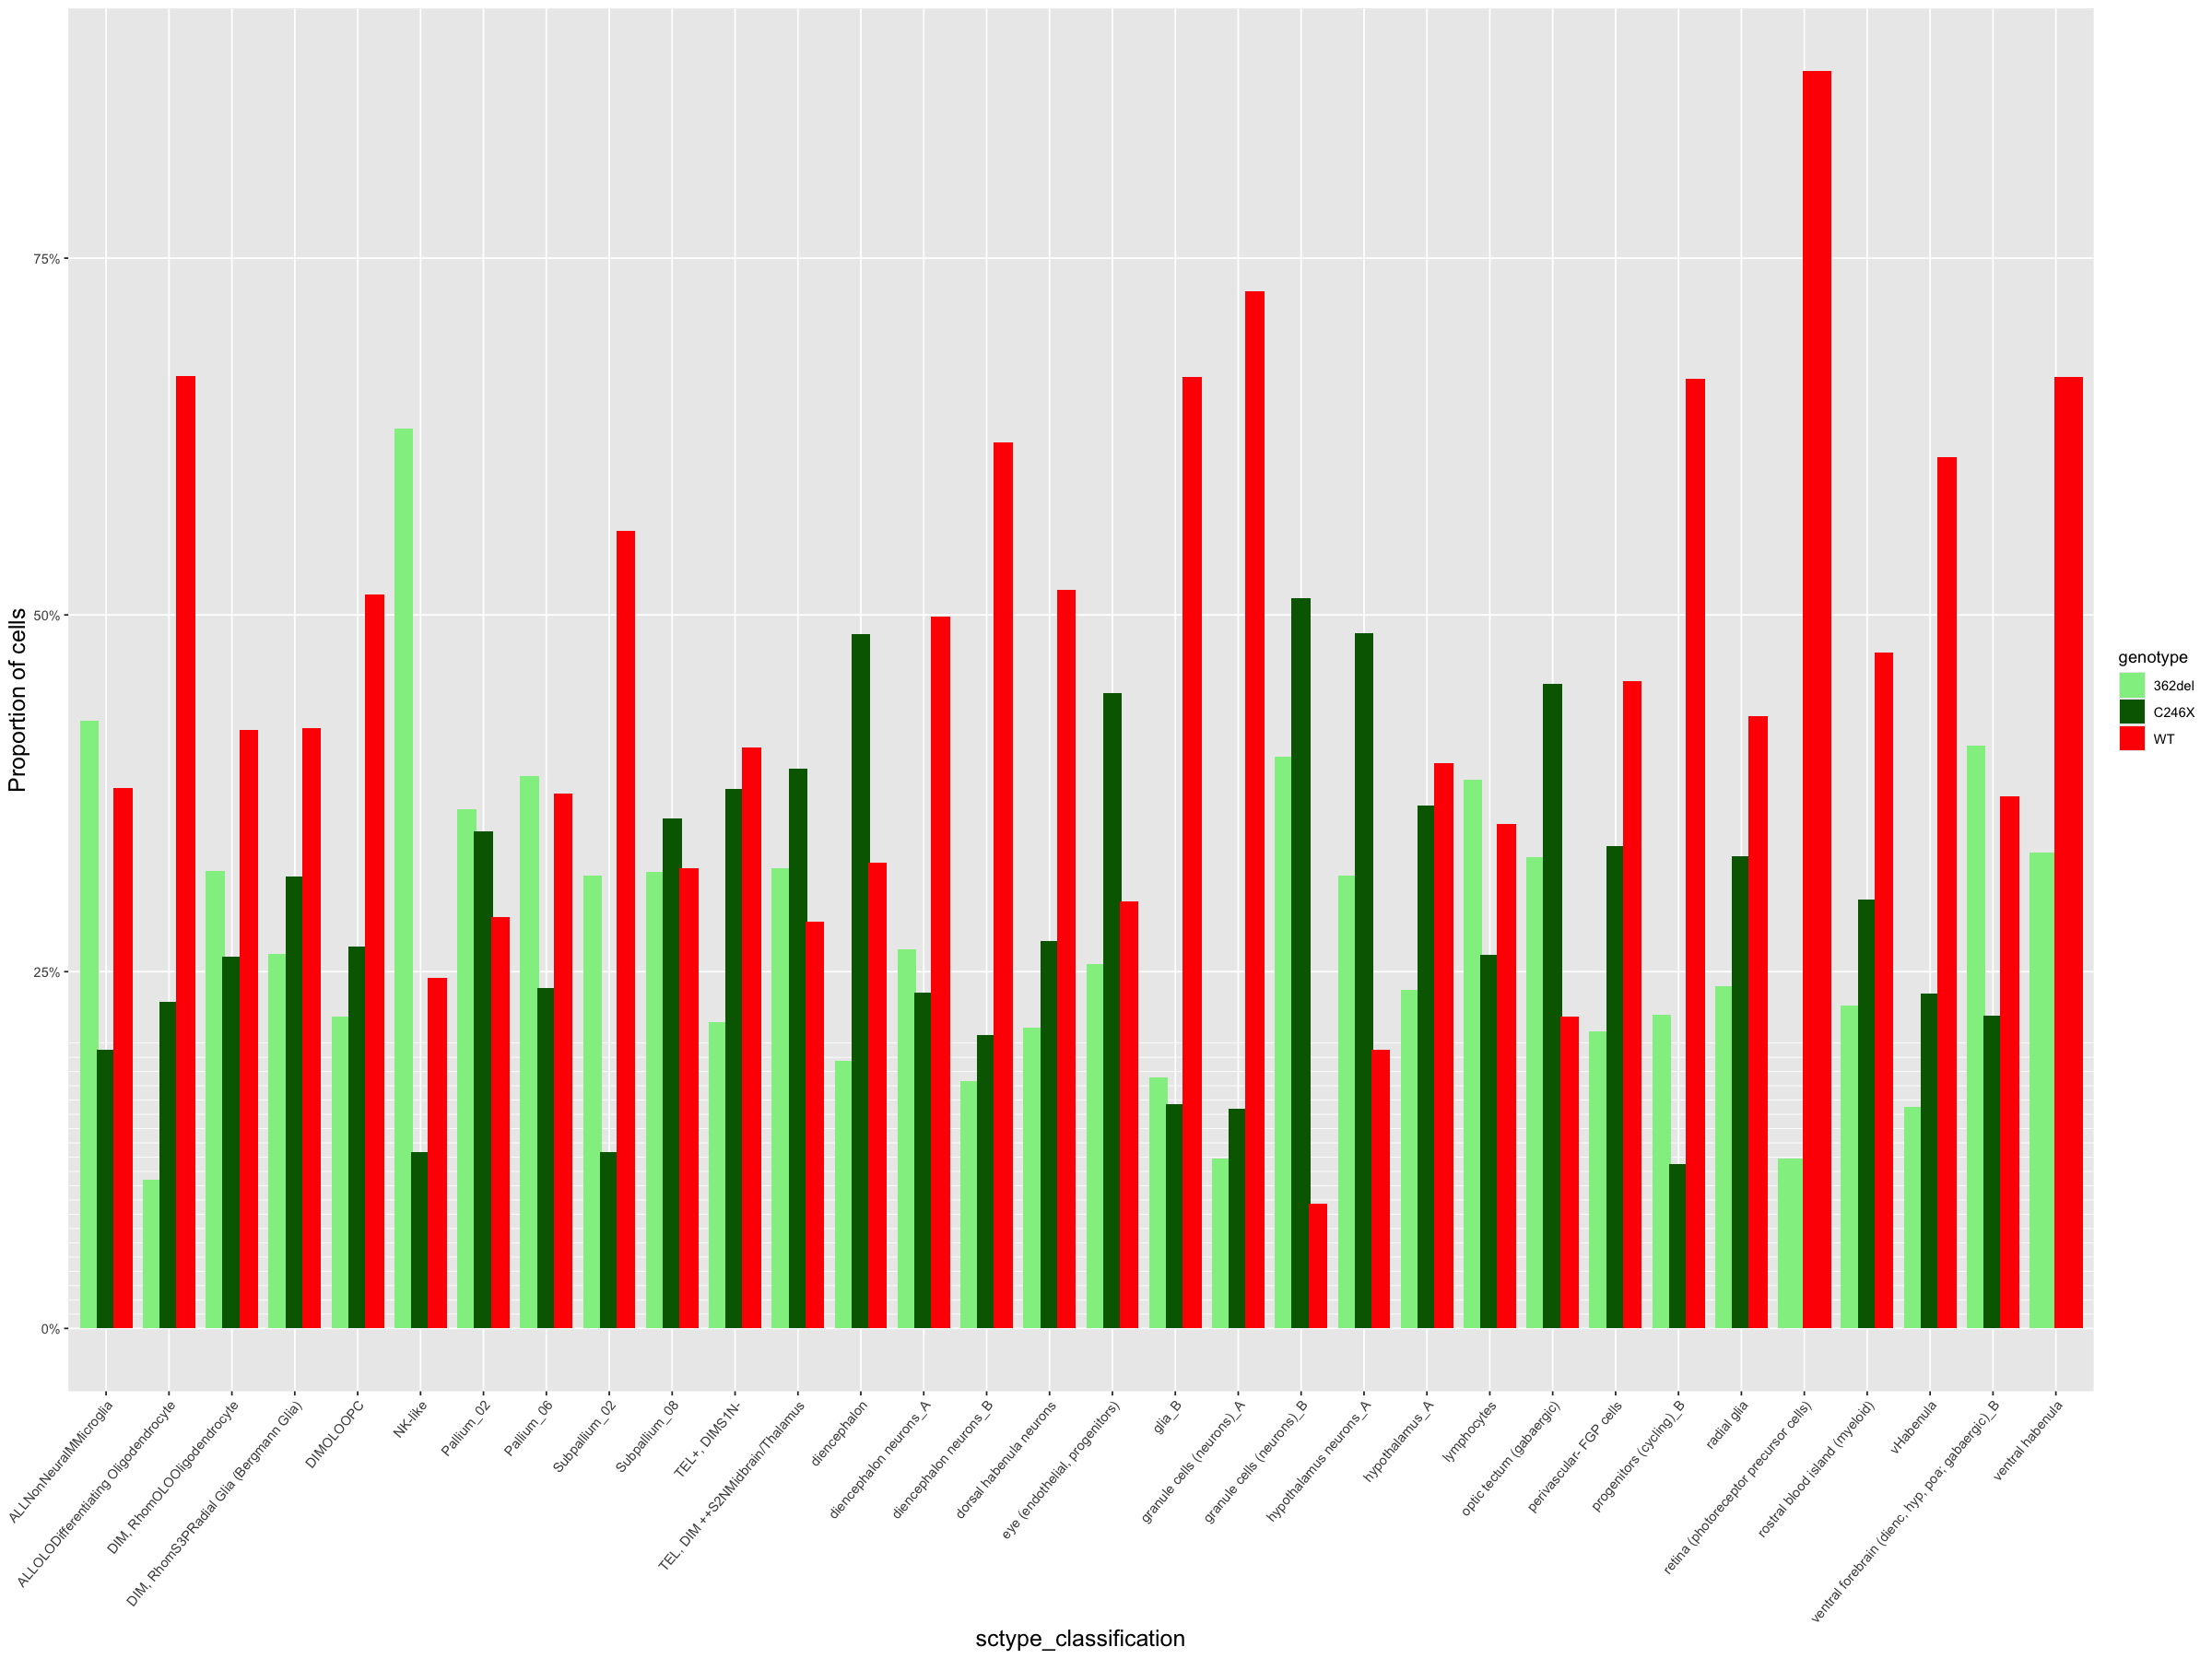

In [2]:
options(repr.plot.width=20, repr.plot.height=15)

# get metadata from the Seurat object
metadata = LOG_NORM_NOVOALL_filt_final@meta.data

# calculate the proportion of cells in each sctype_classification by genotype
metadata_proportions <- metadata %>%
  group_by(genotype, sctype_classification) %>%
  summarise(cell_count = n()) %>%
  group_by(sctype_classification) %>%
  mutate(proportion = cell_count / sum(cell_count))

# create the bar plot
ggplot(metadata_proportions, aes(x = sctype_classification, y = proportion, fill = genotype)) +
  geom_col(position = position_dodge(width = 0.8)) +  # bars side by side
  theme(axis.text.x = element_text(angle = 50, hjust = 1)) + 
  theme(axis.title.x = element_text(size = 15)) + 
  theme(axis.title.y = element_text(size = 15)) +
  labs(y = "Proportion of cells", x = "sctype_classification") +
  scale_y_continuous(minor_breaks = seq(0, 0.20, 0.01), labels = scales::percent) +  # Show y-axis as percentages
  scale_fill_manual(values = c("WT" = "red", "362del" = "lightgreen", "C246X" = "darkgreen")) # Optional: custom color palette

### Filter to chosen classifications

In [25]:
clusters_to_plot = readline(prompt = "Please enter the cluster cell types you wish to plot seperated only by a comma:")

# possible entry: dorsal habenula neurons,VHbenula,ventral habenula,ALLOLODifferentiating Oligodendrocyte,Oligodendrocytes,DIMOLOOPC,radial glia,progenitors (cycling)_,hypothalamus neurons_A,hypothalamus_A,ALLNonNeuralMMicroglia,NK-like

# specify the clusters you want to plot
clusters_to_plot = str_split_1(clusters_to_plot, ",")

Please enter the cluster cell types you wish to plot seperated only by a comma: ALLOLODifferentiating Oligodendrocyte,dorsal habenula neurons,ventral habenula,DIMOLOOPC,radial glia,hypothalamus neurons_A,hypothalamus_A,ALLNonNeuralMMicroglia,NK-like


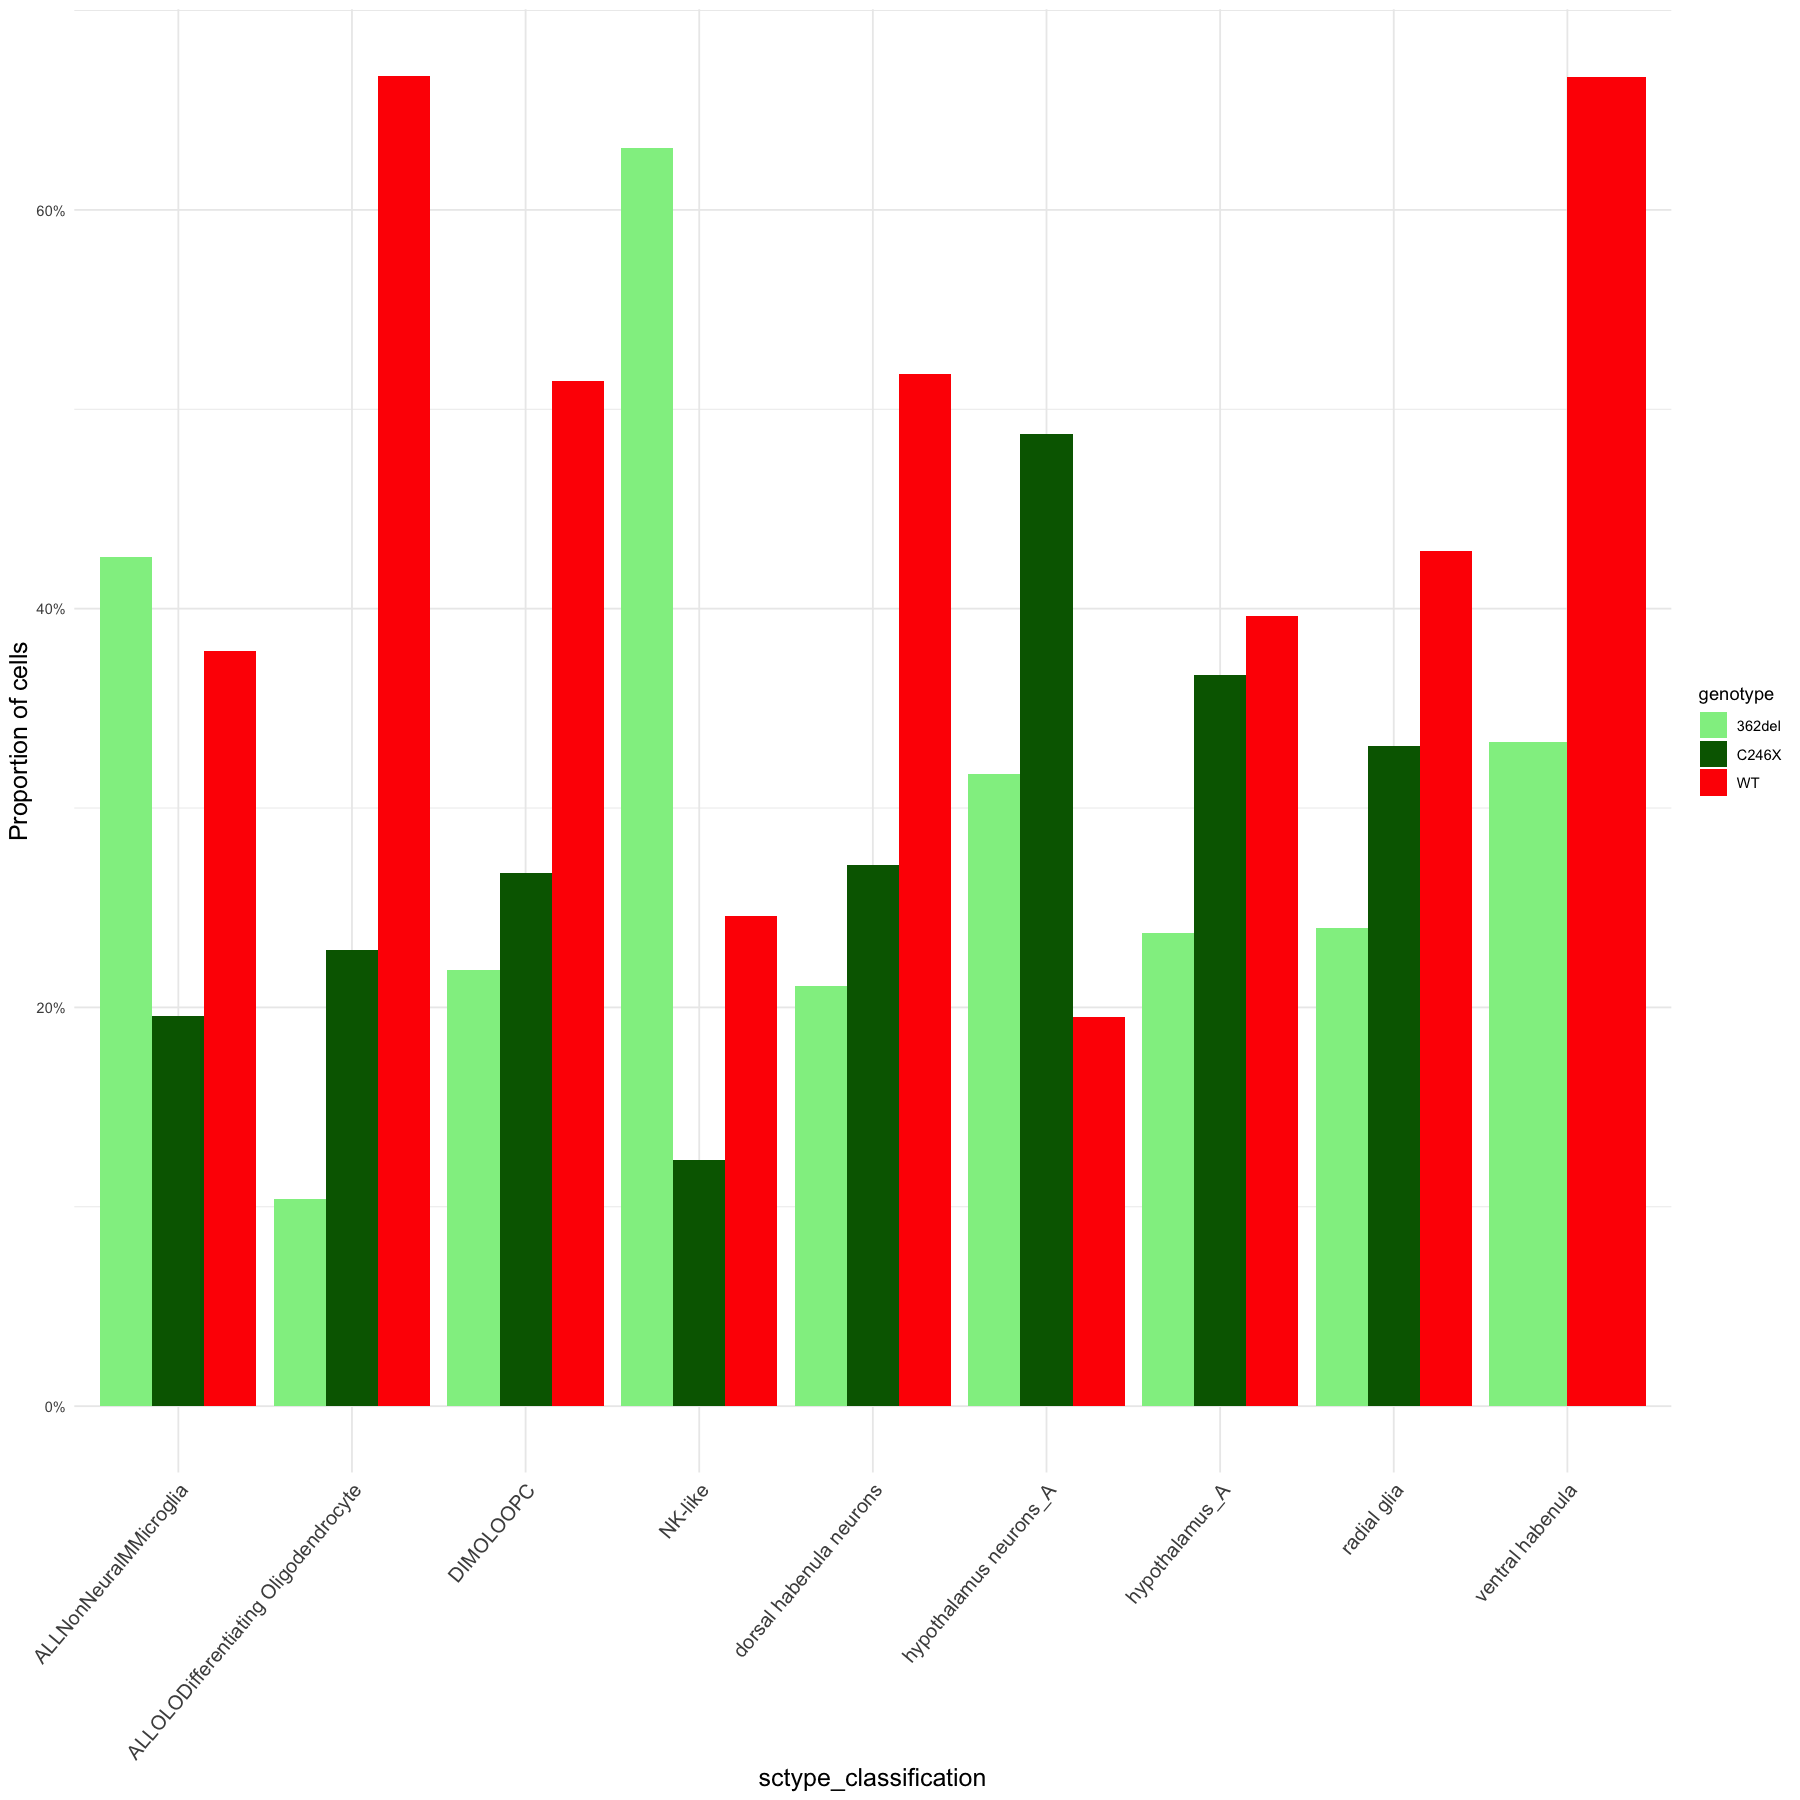

In [26]:
# Filter the metadata to keep only the clusters you want to plot
metadata_proportions_filtered <- metadata_proportions %>%
  filter(sctype_classification %in% clusters_to_plot)

# create the bar plot for the selected clusters
ggplot(metadata_proportions_filtered, aes(x = sctype_classification, y = proportion, fill = genotype)) +
  geom_col(position = position_dodge(width = 0.9)) +  # bars side by side
  theme_minimal() + 
  theme(axis.text.x = element_text(angle = 50, hjust = 1, size = 12)) +  
  theme(axis.title.x = element_text(size = 15)) + 
  theme(axis.title.y = element_text(size = 15)) +
  labs(y = "Proportion of cells", x = "sctype_classification") +
  scale_y_continuous(labels = scales::percent) +  # Show y-axis as percentages
  scale_fill_manual(values = c("WT" = "red", "362del" = "lightgreen", "C246X" = "darkgreen"))  # Optional: custom color palette

## Compare differential expression of cells between conditions within each cluster

In [5]:
# making a distinction between genotypes for each classification
LOG_NORM_NOVOALL_filt_final$celltype.stim <- paste(LOG_NORM_NOVOALL_filt_final$sctype_classification, 
                                                     LOG_NORM_NOVOALL_filt_final$genotype, 
                                                     sep = "_")
Idents(LOG_NORM_NOVOALL_filt_final) <- "celltype.stim"
LOG_NORM_NOVOALL_filt_final = JoinLayers(LOG_NORM_NOVOALL_filt_final)

First choose a test and control genotype set (e.g., C246X vs WT) to compare the differential expression of these groups of cells within each cluster. Then define some functions to save the plots and csv files. Then for the custom gene analysis define the single genes and gene sets.

In [7]:
genotype_test = readline(prompt = "Please enter genotype for test set: ") # e.g., C246X 
genotype_control = readline(prompt = "Please enter genotype for control set: ") # e.g., WT

Please enter genotype for test set:  C246X
Please enter genotype for control set:  WT


In [21]:
## Functions to save files and plots (in separate folders for each cluster)

# Save the DEGs to csv files
output_dir_csv = readline(prompt = "Please enter the output directory to save data for csv files produced: ")

# define function that can be used later (bc using custom filename)
save_csv <- function(df, suffix, test, control, gene, output_dir, row_names, cluster) { # row_names is TRUE or FALSE

  file_name = paste(control, "vs", test, gene, suffix, sep = "_")
    
  output_dir = paste0(output_dir, "_", cluster) # make a new output dir depending on the cluster
  dir.create(output_dir) # create the output dir
    
  fullpath <- file.path(output_dir, file_name) # construct the file path
  write.csv(df, file = fullpath, row.names = row_names)

}

# Save volcano plot
output_dir_plots = readline(prompt = "Please enter the output directory to save plots produced: ")

# define function to save the plot
save_plot = function(plot, suffix, test, control, gene, output_dir, width, height, cluster) { # gene is for later
    file_name = paste(control, "vs", test, gene, suffix, sep = "_")

    output_dir = paste0(output_dir, "_", cluster) # make a new output dir depending on the cluster
    dir.create(output_dir) # create the output dir

    ggsave(filename = file_name, plot = plot, device = pdf, path = output_dir, width = width, height = height)
}

Please enter the output directory to save data for csv files produced:  /Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Expression Analysis output/CSV files
Please enter the output directory to save plots produced:  /Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Expression Analysis output/Plots


In [22]:
# for the custom gene analysis, define the single genes
single_genes = str_split_1(readline(prompt = "Please provide list of genes separated by a comma: "), ",")
p_value_threshold = as.numeric(readline(prompt = "Please provide a p value threshold, e.g., 0.05: "))

Please provide list of genes separated by a comma:  chrn,grin,gabr,drd
Please provide a p value threshold, e.g., 0.05:  0.05


In [23]:
# dir where the custom gene sets file is saved
dir = readline(prompt = "Please enter the directory where the custom gene sets file is saved: ")

Please enter the directory where the custom gene sets file is saved:  ../raw_data/custom_gene_sets_July24.xlsx


In [34]:
options(repr.plot.width=20, repr.plot.height=10)

all_volcano_plots  = list()  # per-cluster single-gene plots
all_volcano_plots2 = list()  # per-cluster gene-set plots

for (cluster in clusters_to_plot) {

    # Define test and control sets for comparison
    Test = paste0(cluster, "_", genotype_test)
    Control = paste0(cluster, "_", genotype_control)

    # Check whether the Test and Control sets exist in the file 
    if (!(Test %in% LOG_NORM_NOVOALL_filt_final$celltype.stim) || !(Control %in% LOG_NORM_NOVOALL_filt_final$celltype.stim)){
        message("Skipping ", cluster, " because one or both identities are missing: ", Test, ", ", Control)
        next
        }

    #### All genes - Differentially expressed genes (DEGs), volcano plots, GSEA ####
    
    # Identify differentially expressed genes between Test and Control
    mono.de <- FindMarkers(LOG_NORM_NOVOALL_filt_final, 
                           ident.1 = Test, 
                           ident.2 = Control, # this should be control as ident.1 is compared to ident.2
                           verbose = FALSE)
    
    de_genes_sorted <- mono.de[order(mono.de$avg_log2FC), ] # sort downregulated --> upregulated
    de_genes_sig_output <- de_genes_sorted[de_genes_sorted$p_val_adj <= 0.05, ] # filter to take only the significant ones

    # save the csv files
    save_csv(de_genes_sorted, "All_DEGs.csv", Test, Control, gene = "", output_dir_csv, TRUE, cluster = cluster) # save all DEGs
    save_csv(de_genes_sig_output, "All_DEGs_pAdj005.csv", Test, Control, gene = "", output_dir_csv, TRUE, cluster = cluster) # save only significant DEGs

    ### Volcano plot ###
    # create custom key-value pairs for 'high', 'low', 'mid' expression by fold-change
    custom_keyvals = function(df) {
        keyvals = case_when(
            df$avg_log2FC < -1 & df$p_val_adj <= 0.05 ~ "Downregulated",
            df$avg_log2FC > 1 & df$p_val_adj <= 0.05 ~ "Upregulated",
            df$avg_log2FC > -1 & df$avg_log2FC < 0 & df$p_val_adj <= 0.05 ~ "Provisionally downregulated",
            df$avg_log2FC < 1 & df$avg_log2FC > 0 & df$p_val_adj <= 0.05 ~ "Provisionally upregulated",
            df$p_val_adj > 0.05 ~ "Not significant"
        )
    
        colour_map = c(
          "Upregulated" = "red3",
          "Downregulated" = "navyblue",
          "Provisionally upregulated" = "orangered2",
          "Provisionally downregulated" = "steelblue1",
          "Not significant" = "grey70"
          )
    
        keyvals_coloured = unname(colour_map[keyvals])
        names(keyvals_coloured) = keyvals
    
        return(keyvals_coloured)
    }
    
    all_genes_volcano = EnhancedVolcano(de_genes_sorted,
                    lab = rownames(de_genes_sorted),
                    x = 'avg_log2FC', y = 'p_val',
                    selectLab = rownames(de_genes_sorted)[which(names(custom_keyvals(de_genes_sorted)) %in% c('Upregulated', 'Downregulated'))],
                    #xlab = bquote(~Log[2]~ 'fold change'),
                    title = paste(Control, "vs", Test, "(All_genes)", sep = " "),
                    #pCutoff = 10e-14,
                    #FCcutoff = 1.0,
                    pointSize = 5, labSize = 4.5,
                    xlim = c(-10,10), ylim = c(0,100),
                    #shape = c(6, 4, 2, 11),
                    colCustom = custom_keyvals(de_genes_sorted),
                    colAlpha = 1,
                    legendPosition = 'right', legendLabSize = 15, legendIconSize = 5.0,
                    #drawConnectors = TRUE,
                    #widthConnectors = 1.0,
                    #colConnectors = 'black',
                    #arrowheads = FALSE,
                    #gridlines.major = TRUE,
                    #gridlines.minor = FALSE,
                    #border = 'partial',
                    #borderWidth = 1.5,
                    #borderColour = 'black'
        )

    # view the plot in line here 
    all_genes_volcano

    # save the volcano plot using the function
    save_plot(all_genes_volcano, "ALL_genes_volcano.pdf", Test, Control, gene = "", output_dir_plots, width = 15, height = 8.27, cluster = cluster)

    ### GSEA output table and plot ###

    # Get output table
    zf_gene_sets = msigdbr(species = "Danio rerio", category = "C5", subcategory = "GO:BP") # online
    
    msigdbr_list = split(x = zf_gene_sets$gene_symbol, f = zf_gene_sets$gs_name)
    
    rankings <- sign(de_genes_sorted$avg_log2FC)*(-log10(de_genes_sorted$p_val)) # we will use the signed p values from spatial DGE as ranking
    de_genes_sorted$gene <- rownames(de_genes_sorted)
    names(rankings) <- de_genes_sorted$gene # genes as names
    head(rankings)
    rankings <- sort(rankings, decreasing = TRUE) # sort genes by ranking
    
    max_ranking <- max(rankings[is.finite(rankings)])
    min_ranking <- min(rankings[is.finite(rankings)])
    rankings <- replace(rankings, rankings > max_ranking, max_ranking * 10)
    rankings <- replace(rankings, rankings < min_ranking, min_ranking * 10)
    rankings <- sort(rankings, decreasing = TRUE) # sort genes by ranking
    
    GSEA_output_table = fgsea(pathways = msigdbr_list, # List of gene sets to check
                     stats = rankings,
                     scoreType = 'std', # in this case we have both pos and neg rankings. if only pos or neg, set to 'pos', 'neg'
                     minSize = 10,
                     maxSize = 500,
                     nproc = 1) # for parallelisation
    
    GSEA_output_table = as.data.frame(GSEA_output_table) %>%
                                            arrange(desc(NES)) %>% # descending order in terms of normalised enrichment score
                                            mutate(leadingEdge = sapply(leadingEdge, function(x) paste(x, collapse = ","))) # leading edge is list of genes in that pathway that contributed most to the enrichment score
                                                                        
    GSEA_output_df_sig = GSEA_output_table %>% filter(padj <= 0.05) # filter for significant

    # Save the GSEA output tables to csv files
    save_csv(GSEA_output_table, "GSEA.csv", Test, Control, gene = "", output_dir_csv, FALSE, cluster = cluster)
    save_csv(GSEA_output_df_sig, "GSEA_pAdj005.csv", Test, Control, gene = "", output_dir_csv, FALSE, cluster = cluster)

    # GSEA Plot
    options(repr.plot.width=15, repr.plot.height=15)
    
    gsea_plot = ggplot(GSEA_output_df_sig, aes(x = reorder(pathway, NES), y = NES, fill = NES)) + 
      geom_bar(stat = "identity") +
      ylim(-2.5, 2.5) +
      coord_flip() +
      scale_fill_gradient2(low = "blue", mid = "pink", high = "red", midpoint = 0) +
      theme_minimal()

    # View the plot in line here                                                                     
    gsea_plot 
                                                                        
    # Save the GSEA plot 
    save_plot(gsea_plot, "GSEA_plot.pdf", Test, Control, gene = "", output_dir_plots, width = 15, height = 15, cluster = cluster)

    #### Custom gene analysis (single gene) ####
    cluster_volcano_plots = list()  # list for THIS cluster 

    for (gene in single_genes) {
        
        # subset the data for the specific gene
        de_subset_temp = de_genes_sorted[grep(gene, rownames(de_genes_sorted)), ]

        # skip if this gene is not found
        if (nrow(de_subset_temp) == 0) {
         message("No rows found for gene '", gene, "' in cluster ", cluster, ". Skipping.")
         next
          }
    
        # save the DEG csv file for this gene
        save_csv(de_subset_temp, ".csv", Test, Control, gene = gene, output_dir_csv, TRUE, cluster = cluster)
    
        # generate custom key-value pairs for expression using function from before
        keyvals = custom_keyvals(de_subset_temp)
        transparent_color <- rgb(0, 0, 0, alpha = 0)  # Transparent black color
    
        # volcano plot
        p = EnhancedVolcano(de_subset_temp,
                      lab = rownames(de_subset_temp),
                      x = 'avg_log2FC',
                      y = 'p_val',
                      selectLab = rownames(de_subset_temp)[which(names(keyvals) %in% c('Upregulated', 'Downregulated', 'Provisionally upregulated', 'Provisionally downregulated'))],
                      xlab = bquote(~Log[2]~ 'fold change'),
                      title = gene,
                      pointSize = 5,
                      labSize = 6,
                      xlim = c(-10,10),
                      ylim = c(0,100),
                      colCustom = keyvals,
                      colAlpha = 1,
                      legendPosition = 'right',
                      legendLabSize = 15,
                      legendIconSize = 5.0,
                      drawConnectors = FALSE,
                      widthConnectors = 1.0,
                      colConnectors = transparent_color,
                      arrowheads = FALSE,
                      labCol = 'black')
    
        cluster_volcano_plots[[paste0("plot", gene)]] = p  
        all_volcano_plots[[cluster]] = cluster_volcano_plots # save to big list to make the grid plot later
    
        save_plot(p, "volcano_plot.pdf", Test, Control, gene = gene, output_dir_plots, width = 15, height = 10, cluster = cluster)

        }

    #### Custom gene analysis (gene sets) ####                                                                
    # import custom gene sets in 
    custom_gene_sets_July24 = read_excel(dir)
    
    # extract gene sets and keep the gene set names from the first column
    gene_sets_list = apply(custom_gene_sets_July24, 1, function(x) na.omit(as.character(x[2:length(x)])))
    
    # assign the gene set names as the names of the list
    names(gene_sets_list) = custom_gene_sets_July24$set_name

    # Volcano plots 
    cluster_volcano_plots2 = list()

    for (name in names(gene_sets_list)) {

        # get the gene set for gene 
        gene_set = gene_sets_list[[name]]
    
        # Exact match of genes from the gene set in the row names of de_genes_sorted
        matched_genes = match(gene_set, rownames(de_genes_sorted))
    
        # remove NAs (genes not found)
        matched_genes = matched_genes[!is.na(matched_genes)]
        
        # check if any genes from the gene set are found
        if(length(matched_genes) == 0) {
            message("No genes from the gene set ", name, " found in the data.")
            next # move on
        }
    
        # subset the data using the matched genes
        de_subset_temp <- de_genes_sorted[matched_genes, , drop = FALSE]
    
        # save the DEGs csv file for this gene set
        save_csv(de_subset_temp, ".csv", Test, Control, gene = name, output_dir_csv, TRUE, cluster = cluster)
    
        # custom keyvals 
        keyvals = custom_keyvals(de_subset_temp)
        transparent_color <- rgb(0, 0, 0, alpha = 0)  # transparent black color
    
        # volcano plots
        p = EnhancedVolcano(de_subset_temp,
                      lab = rownames(de_subset_temp),
                      x = 'avg_log2FC',
                      y = 'p_val',
                      selectLab = rownames(de_subset_temp)[which(names(keyvals) %in% c('Upregulated', 'Downregulated', 'Provisionally upregulated', 'Provisionally downregulated'))],
                      xlab = bquote(~Log[2]~ 'fold change'),
                      title = name,
                      pointSize = 5,
                      labSize = 6,
                      xlim = c(-10,10),
                      ylim = c(0,100),
                      colCustom = keyvals,
                      colAlpha = 1,
                      legendPosition = 'right',
                      legendLabSize = 15,
                      legendIconSize = 5.0,
                      drawConnectors = FALSE,
                      widthConnectors = 1.0,
                      colConnectors = transparent_color,
                      arrowheads = FALSE,
                      labCol = 'black')
    
        cluster_volcano_plots2[[paste0("plot", name)]] = p
        all_volcano_plots2[[cluster]] = cluster_volcano_plots2 # save to big list to make the grid plot later
    
        save_plot(p, "volcano_plot.pdf", Test, Control, gene = name, output_dir_plots, width = 15, height = 10, cluster = cluster)
    }
                                                                            
    }

Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Expression Analysis output/CSV files_ALLOLODifferentiating Oligodendrocyte' already exists”
Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Expression Analysis output/CSV files_ALLOLODifferentiating Oligodendrocyte' already exists”
Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Expression Analysis output/Plots_ALLOLODifferentiating Oligodendrocyte' already exists”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (8.99% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”


  |======================================================================| 100%



Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Expression Analysis output/CSV files_ALLOLODifferentiating Oligodendrocyte' already exists”
Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Expression Analysis output/CSV files_ALLOLODifferentiating Oligodendrocyte' already exists”
Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Expression Analysis output/Plots_ALLOLODifferentiating Oligodendrocyte' already exists”
Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Expression Analysis output/CSV files_ALLOLODifferentiating Oligodendrocyte' already exists”
Warning message in dir.create(output_dir):
“'/Users/sads

  |======================================================================| 100%



Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Expression Analysis output/CSV files_dorsal habenula neurons' already exists”
Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Expression Analysis output/CSV files_dorsal habenula neurons' already exists”
Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Expression Analysis output/Plots_dorsal habenula neurons' already exists”
Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Expression Analysis output/CSV files_dorsal habenula neurons' already exists”
Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSing

...

Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Expression Analysis output/CSV files_hypothalamus_A' already exists”
Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Expression Analysis output/CSV files_hypothalamus_A' already exists”
Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Expression Analysis output/Plots_hypothalamus_A' already exists”
Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Expression Analysis output/CSV files_hypothalamus_A' already exists”
Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Exp

  |======================================================================| 100%



Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Expression Analysis output/CSV files_ALLNonNeuralMMicroglia' already exists”
Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Expression Analysis output/CSV files_ALLNonNeuralMMicroglia' already exists”
Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Expression Analysis output/Plots_ALLNonNeuralMMicroglia' already exists”
Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Expression Analysis output/CSV files_ALLNonNeuralMMicroglia' already exists”
Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapor

  |======================================================================| 100%



Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Expression Analysis output/CSV files_NK-like' already exists”
Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Expression Analysis output/CSV files_NK-like' already exists”
Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Expression Analysis output/Plots_NK-like' already exists”
No rows found for gene 'chrn' in cluster NK-like. Skipping.

Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapore/NUS/ScRNA/src/Differential Expression Analysis output/CSV files_NK-like' already exists”
Warning message in dir.create(output_dir):
“'/Users/sadsa/Library/CloudStorage/OneDrive-NationalUniversityofSingapo

### Optional: viewing the volcano plots for custom single genes and gene sets in-line here for each cluster

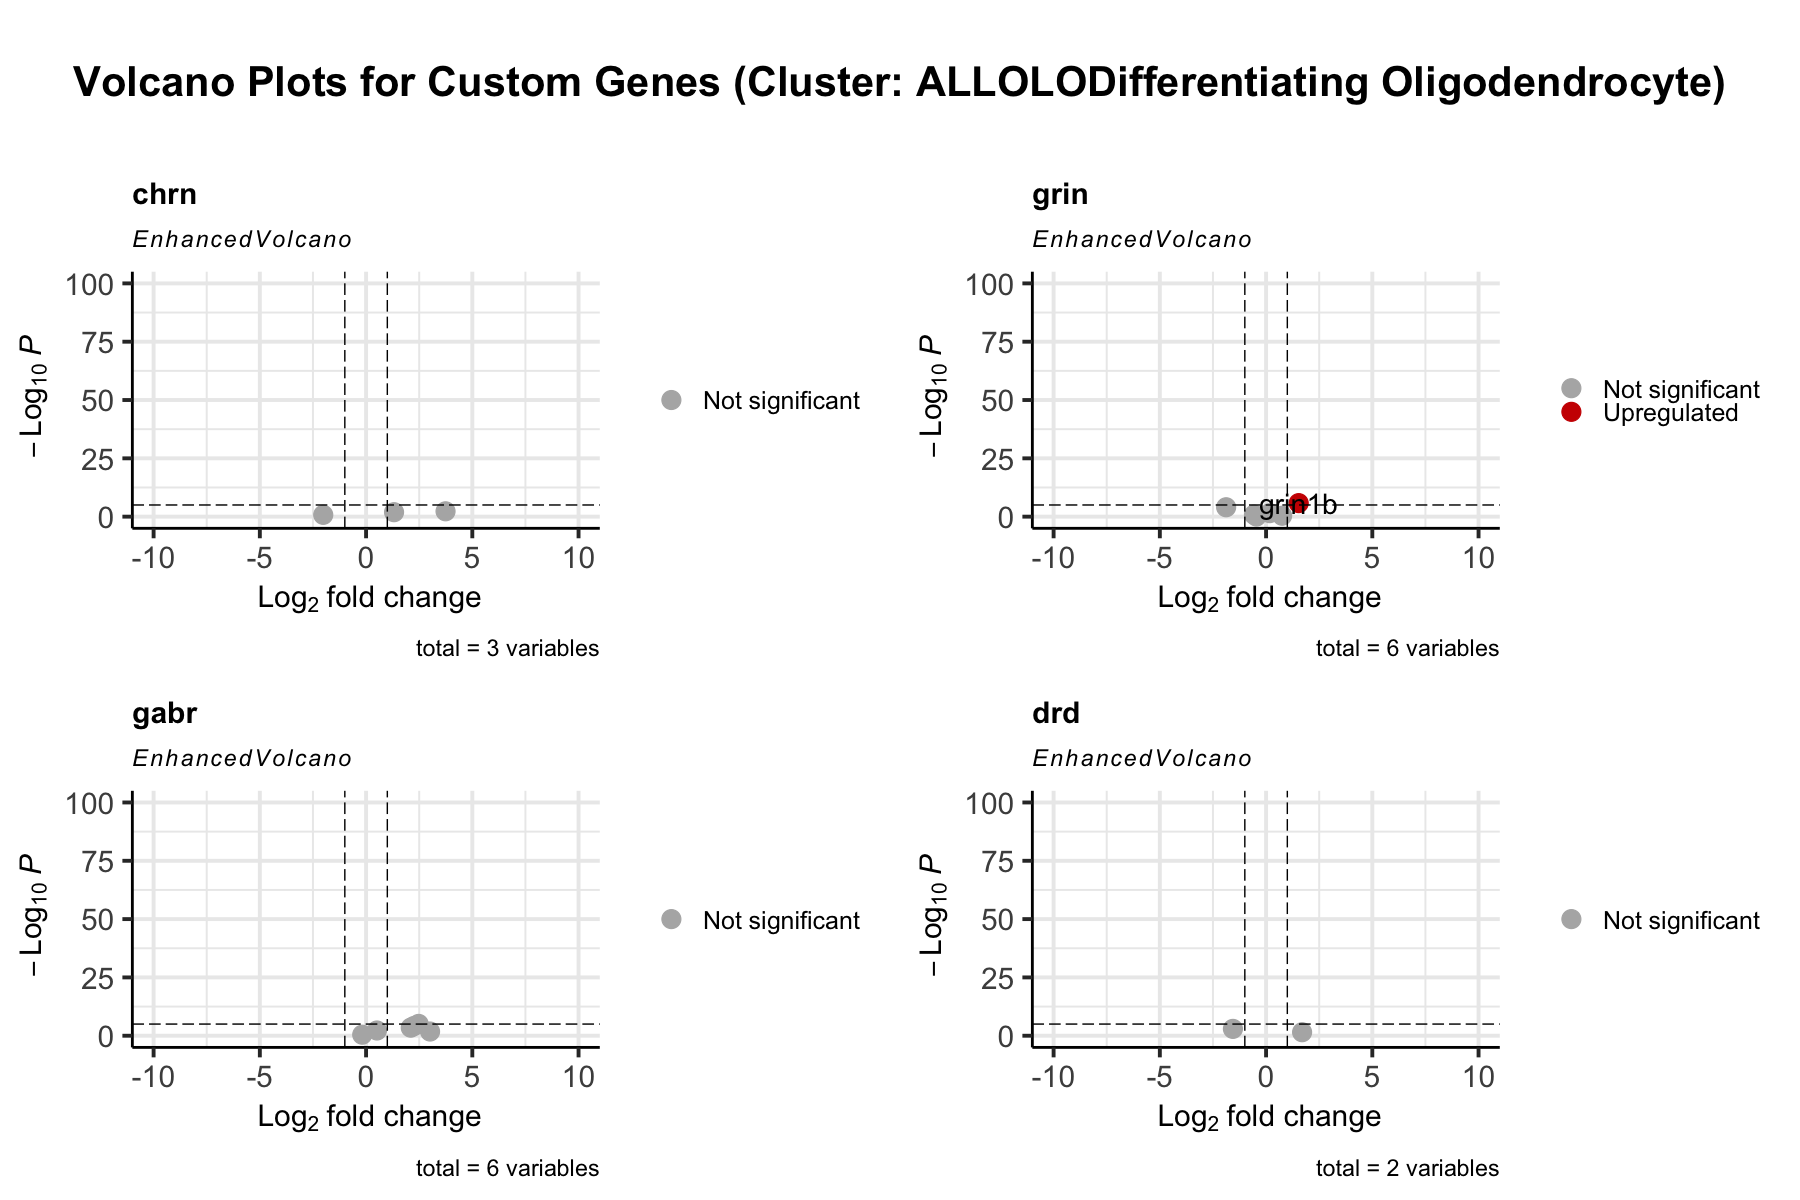

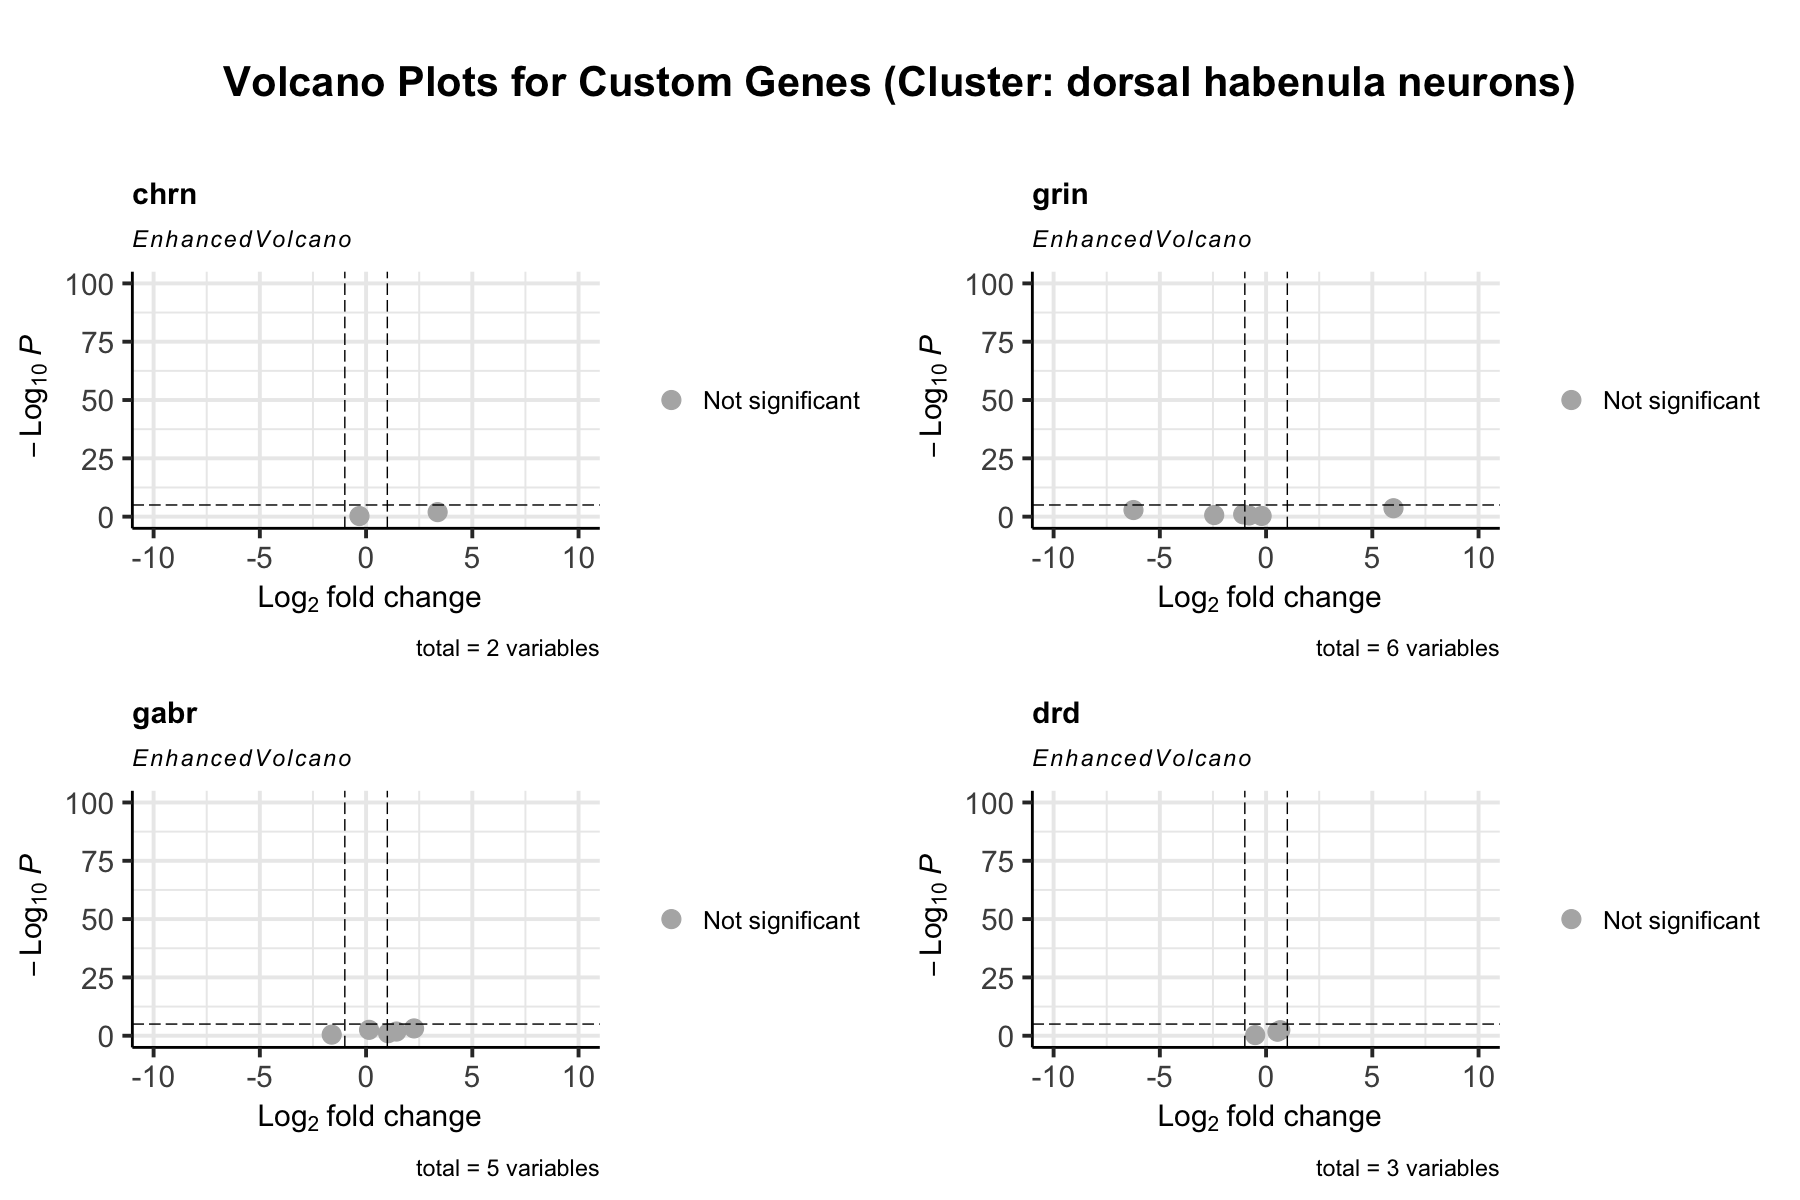

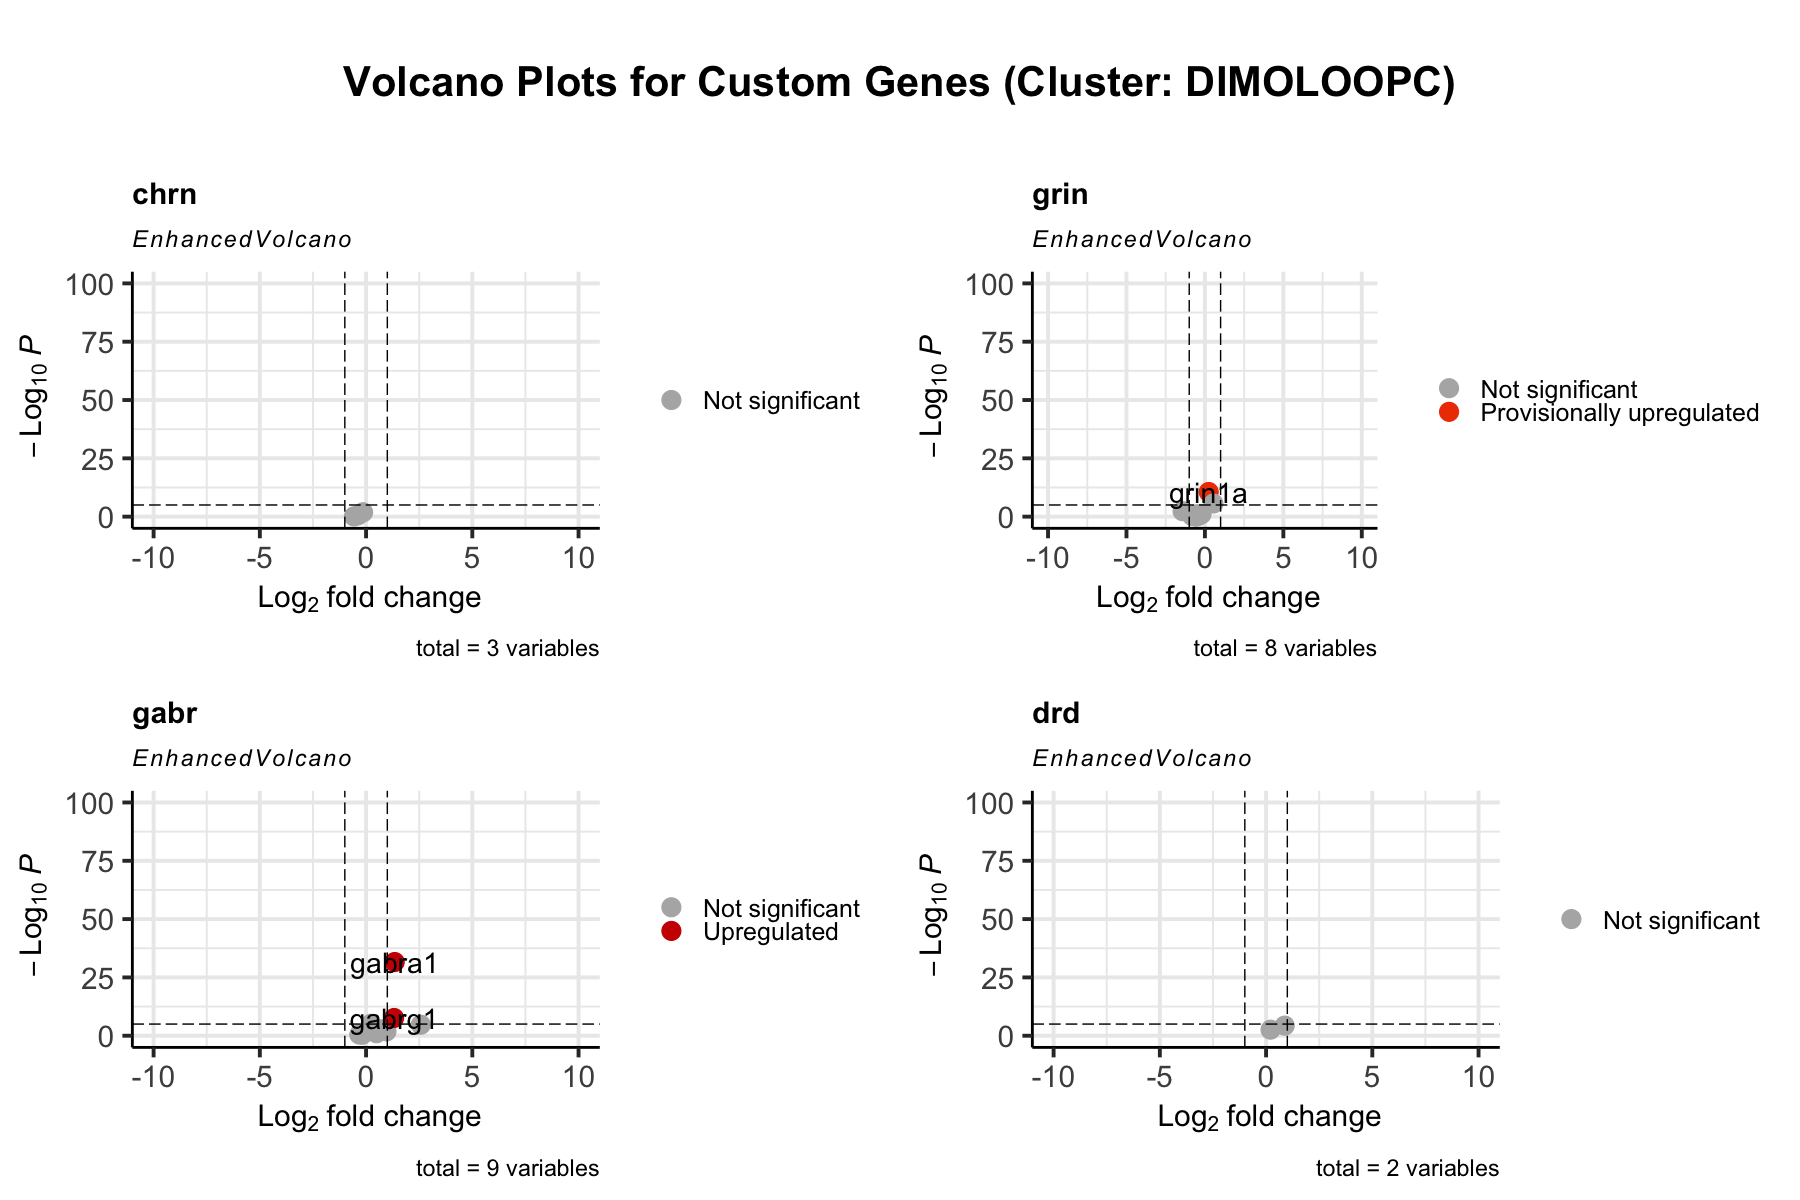

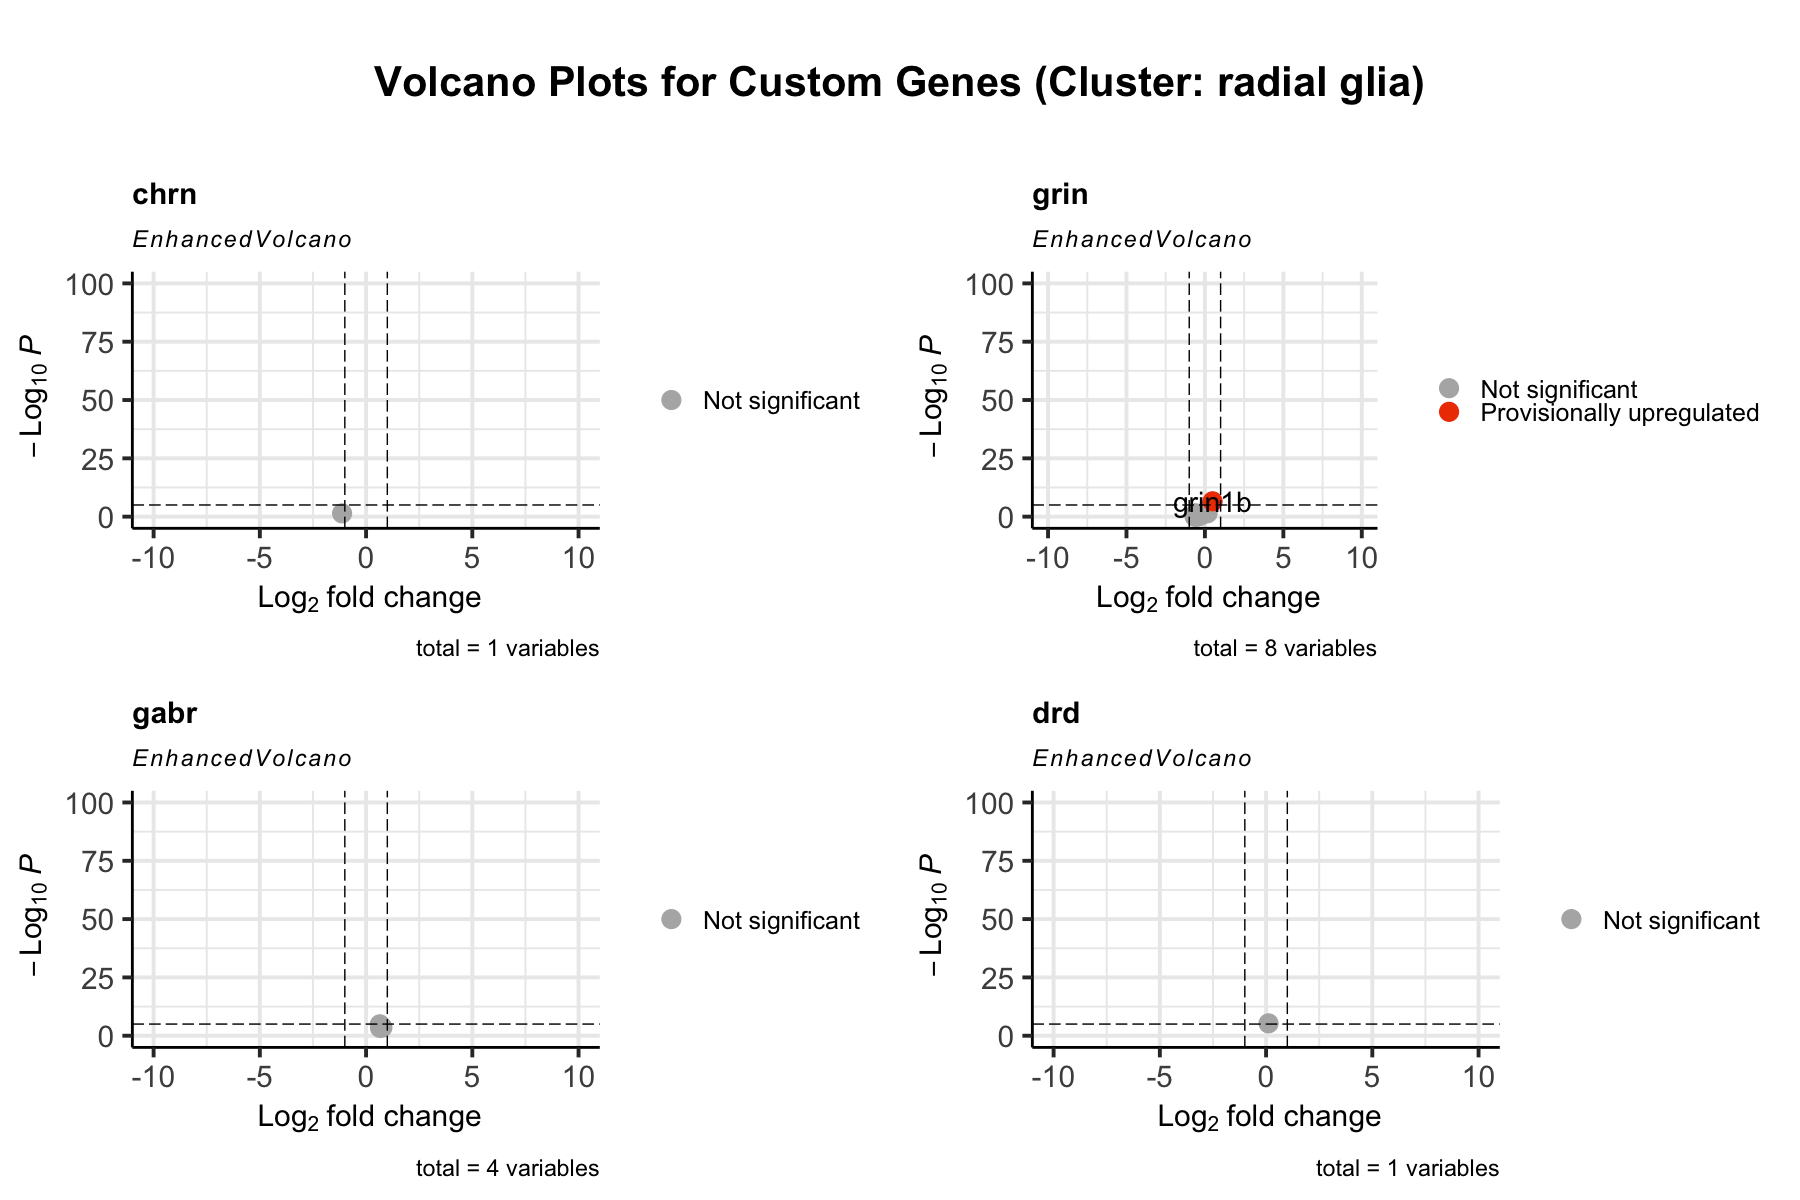

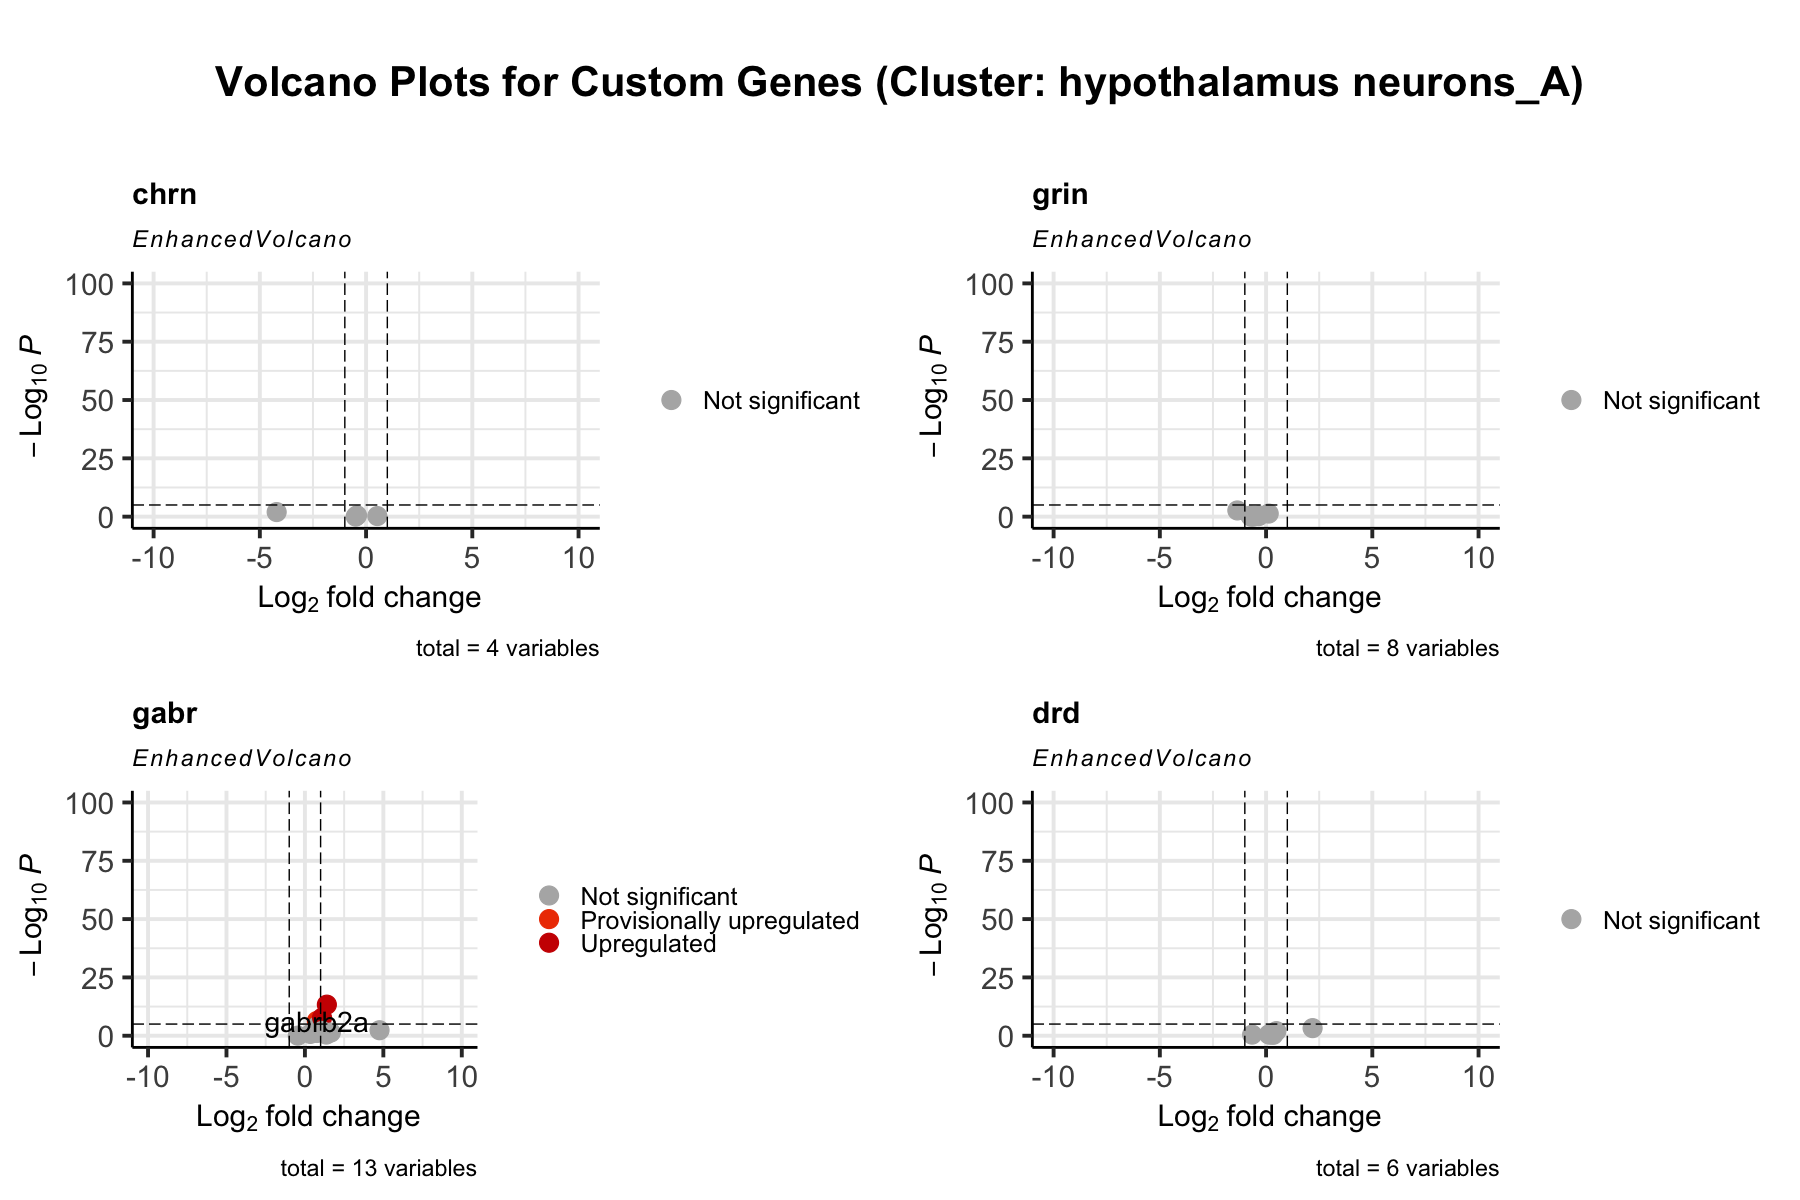

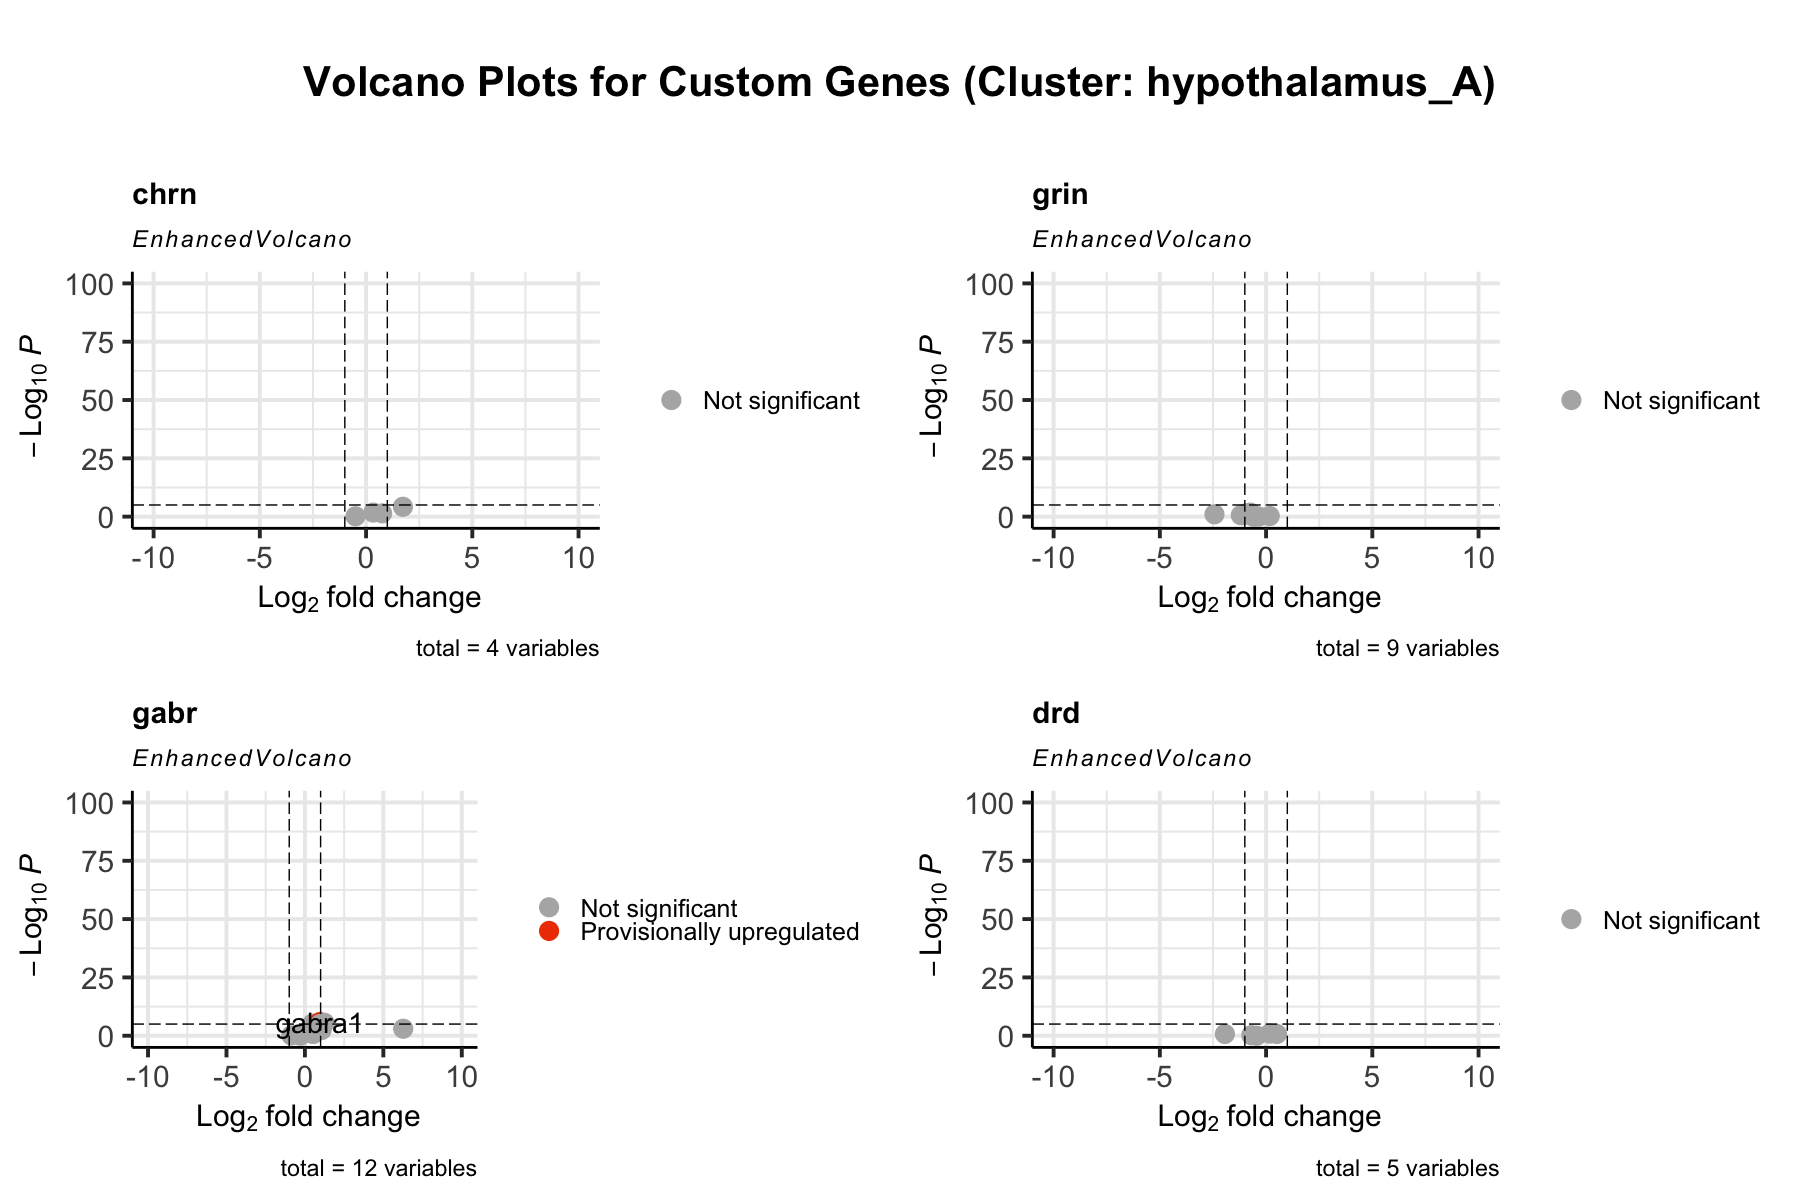

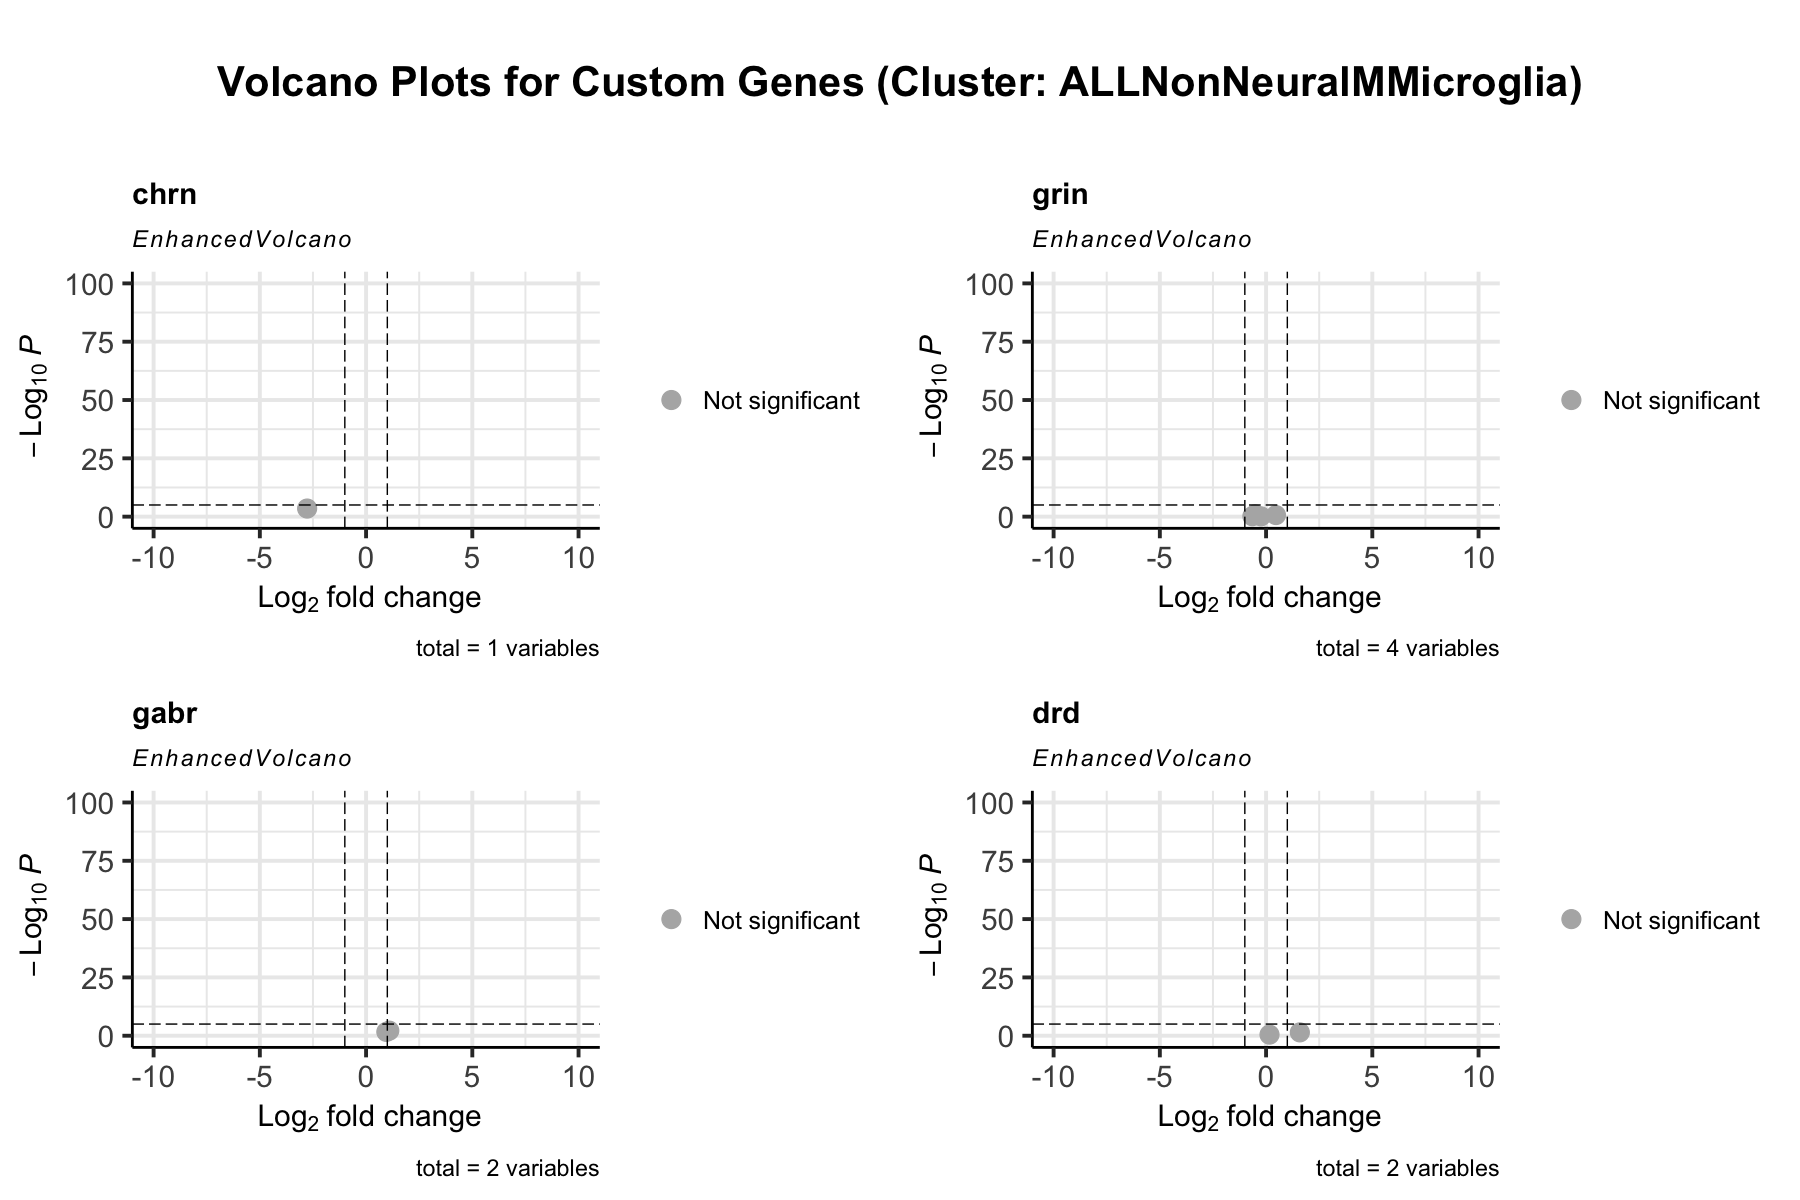

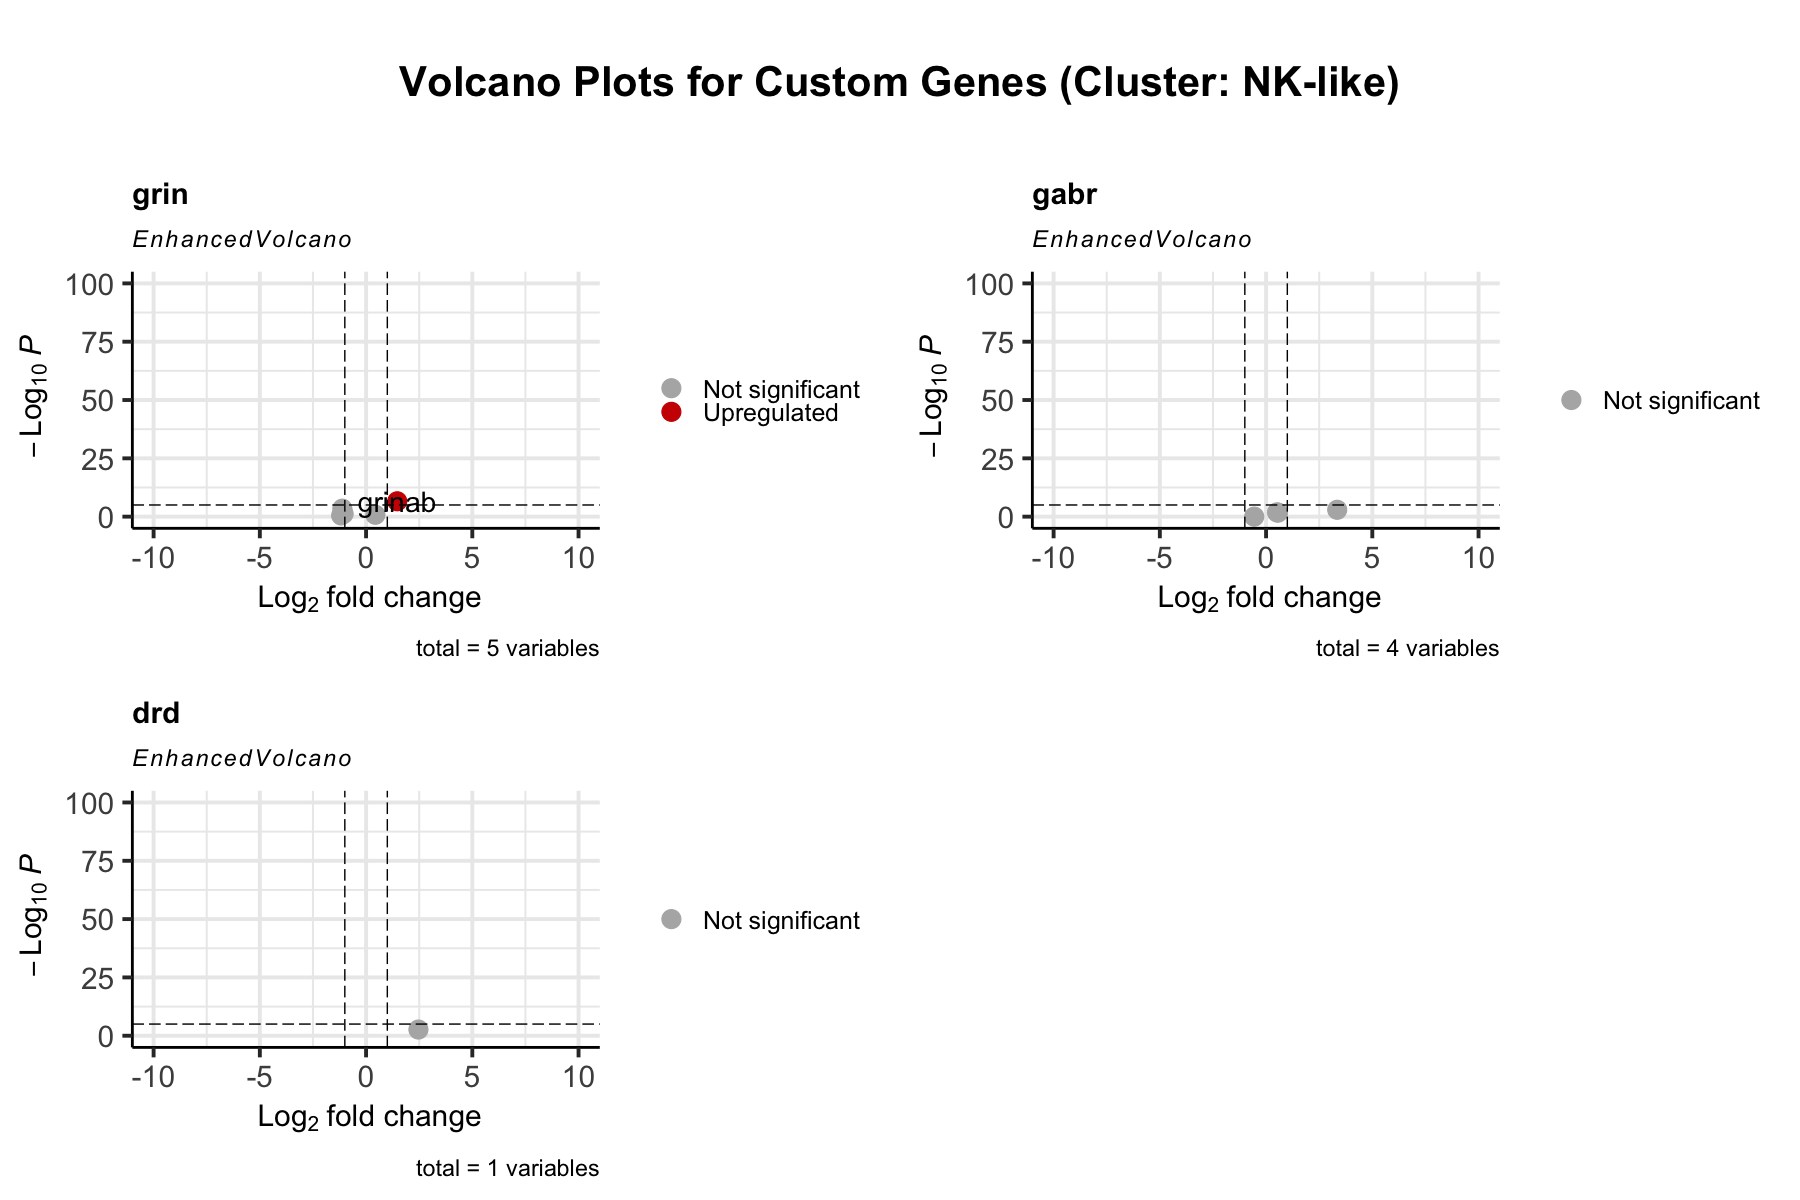

In [51]:
options(repr.plot.height = 10, repr.plot.width = 15)

# Single-gene volcano grids, per cluster
for (cluster in names(all_volcano_plots)) {
  vp = all_volcano_plots[[cluster]]

  if (length(vp) == 0) {
    next
  }

  grid.arrange(
    grobs = vp,
    ncol = ceiling(length(vp)/2),
    top = textGrob(
      paste0("\nVolcano Plots for Custom Genes (Cluster: ", cluster, ")\n"),
      gp = gpar(fontsize = 25, fontface = "bold")
    )
  )
}

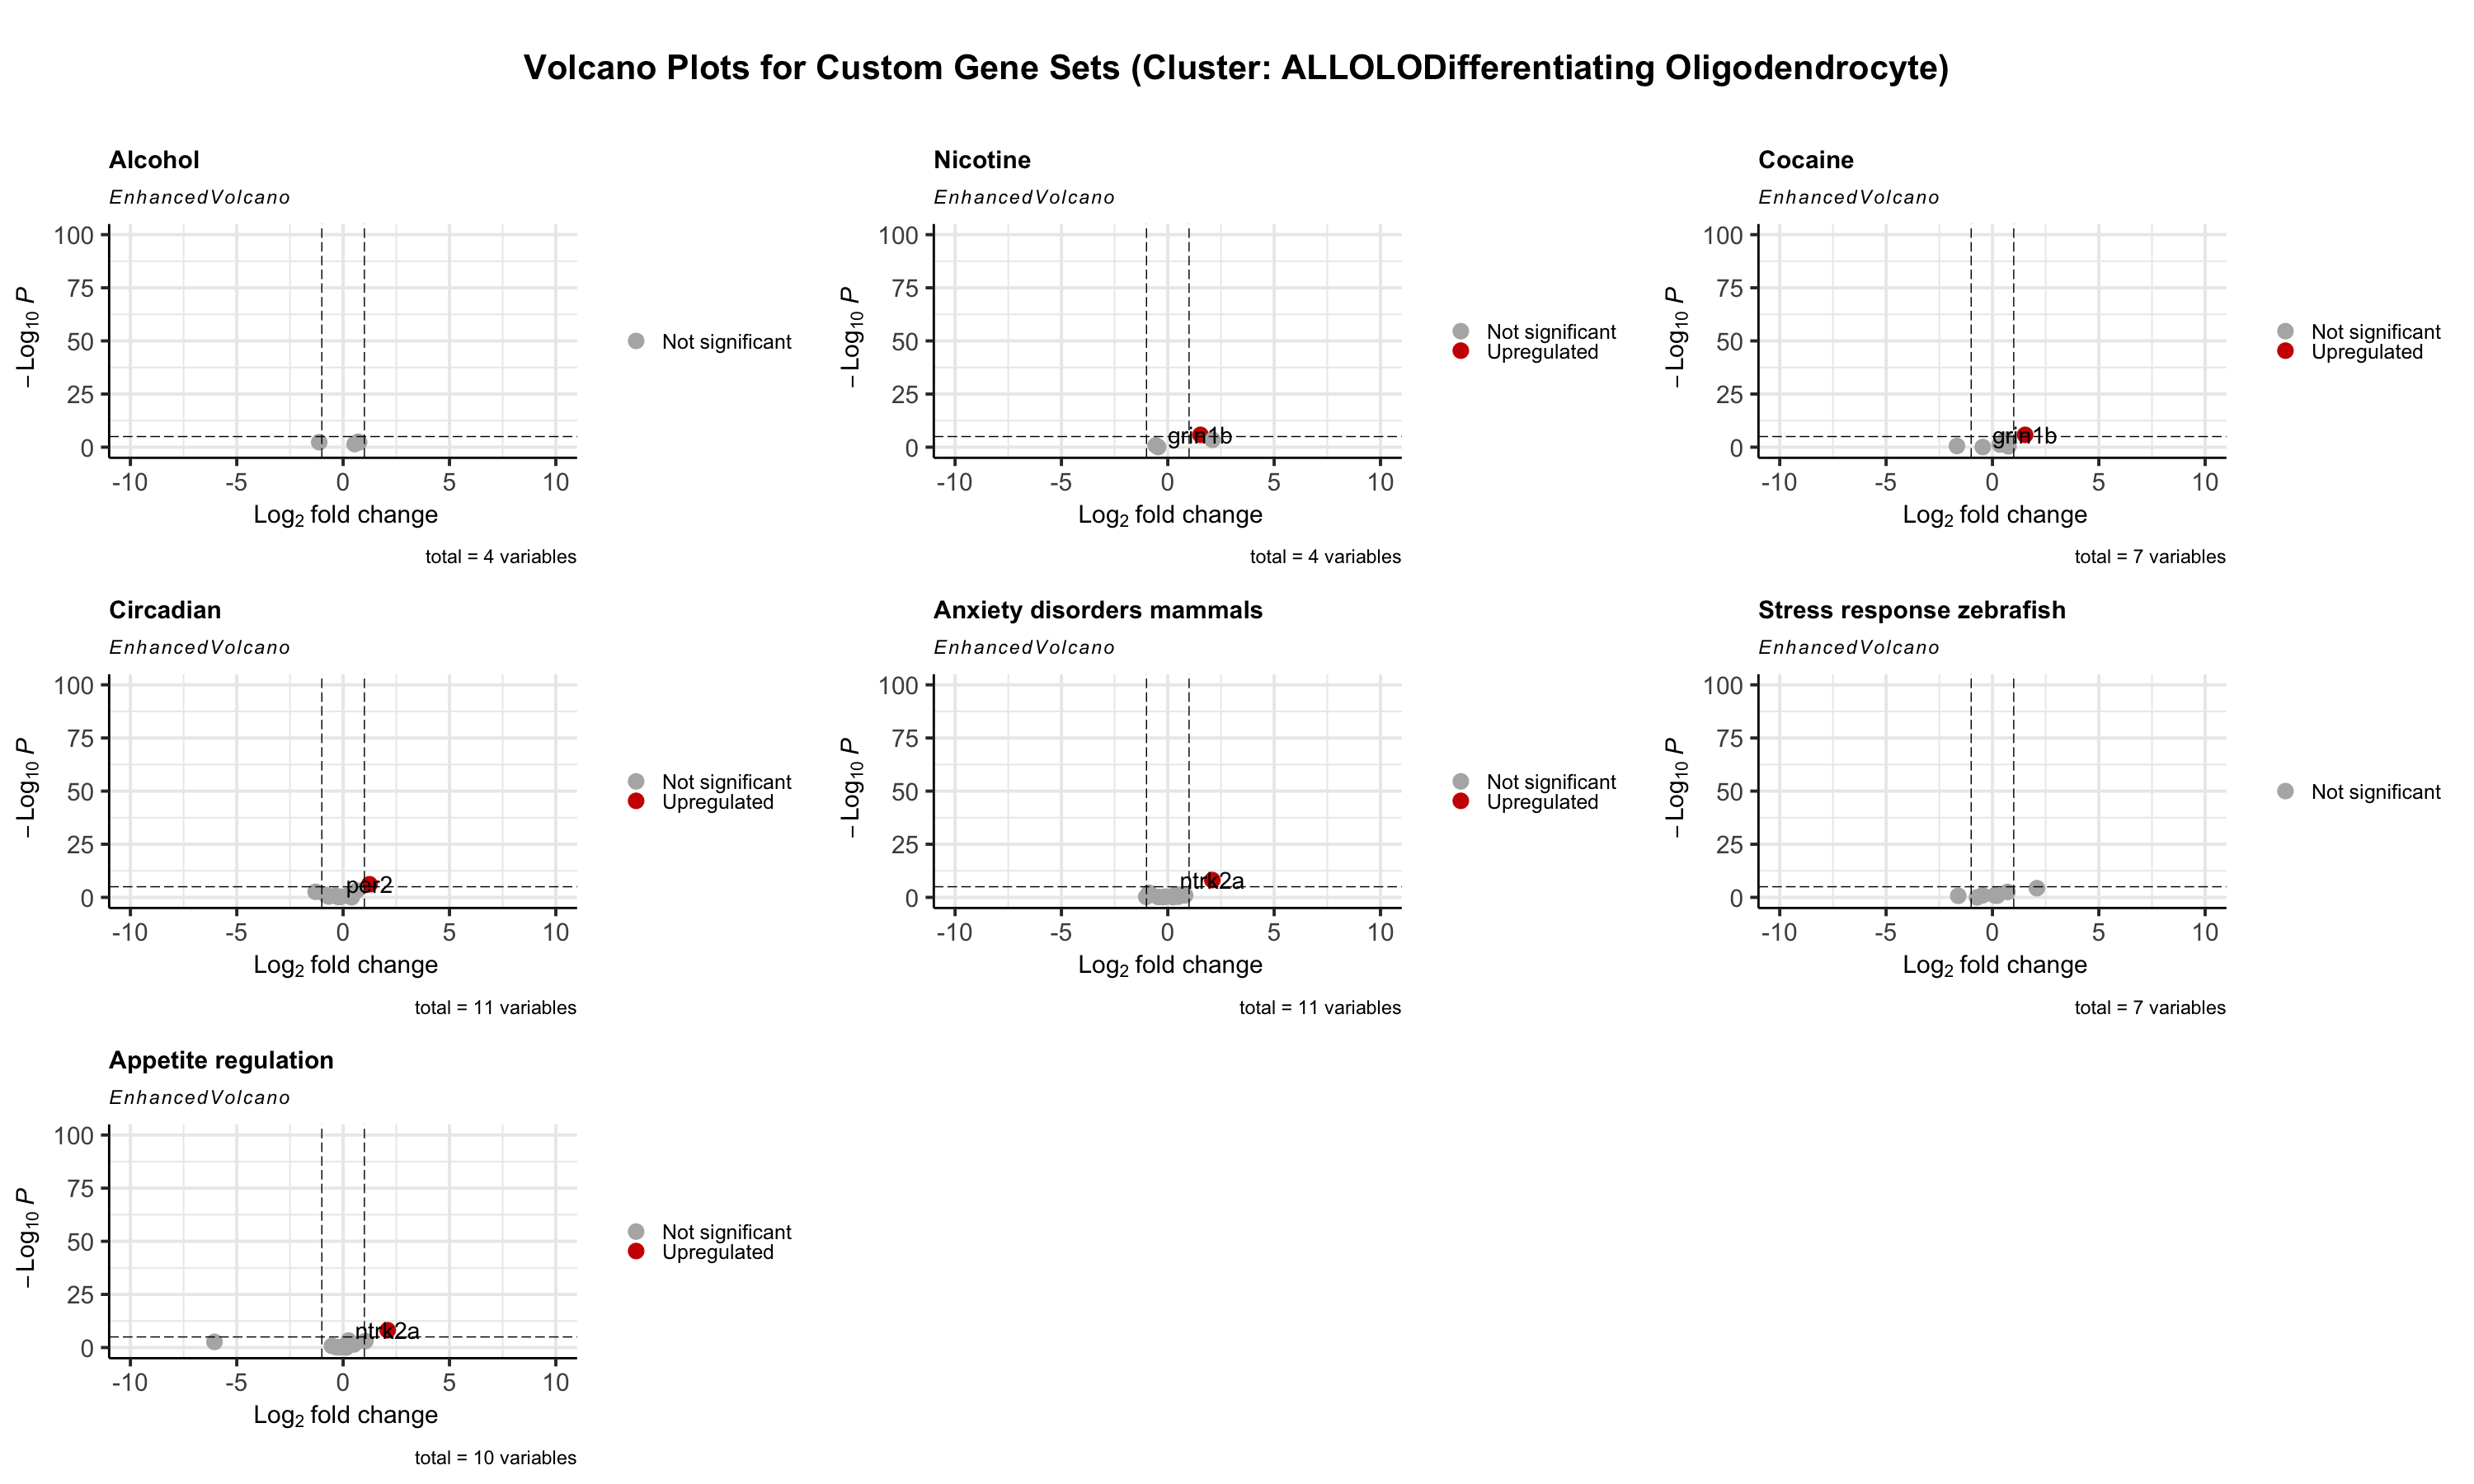

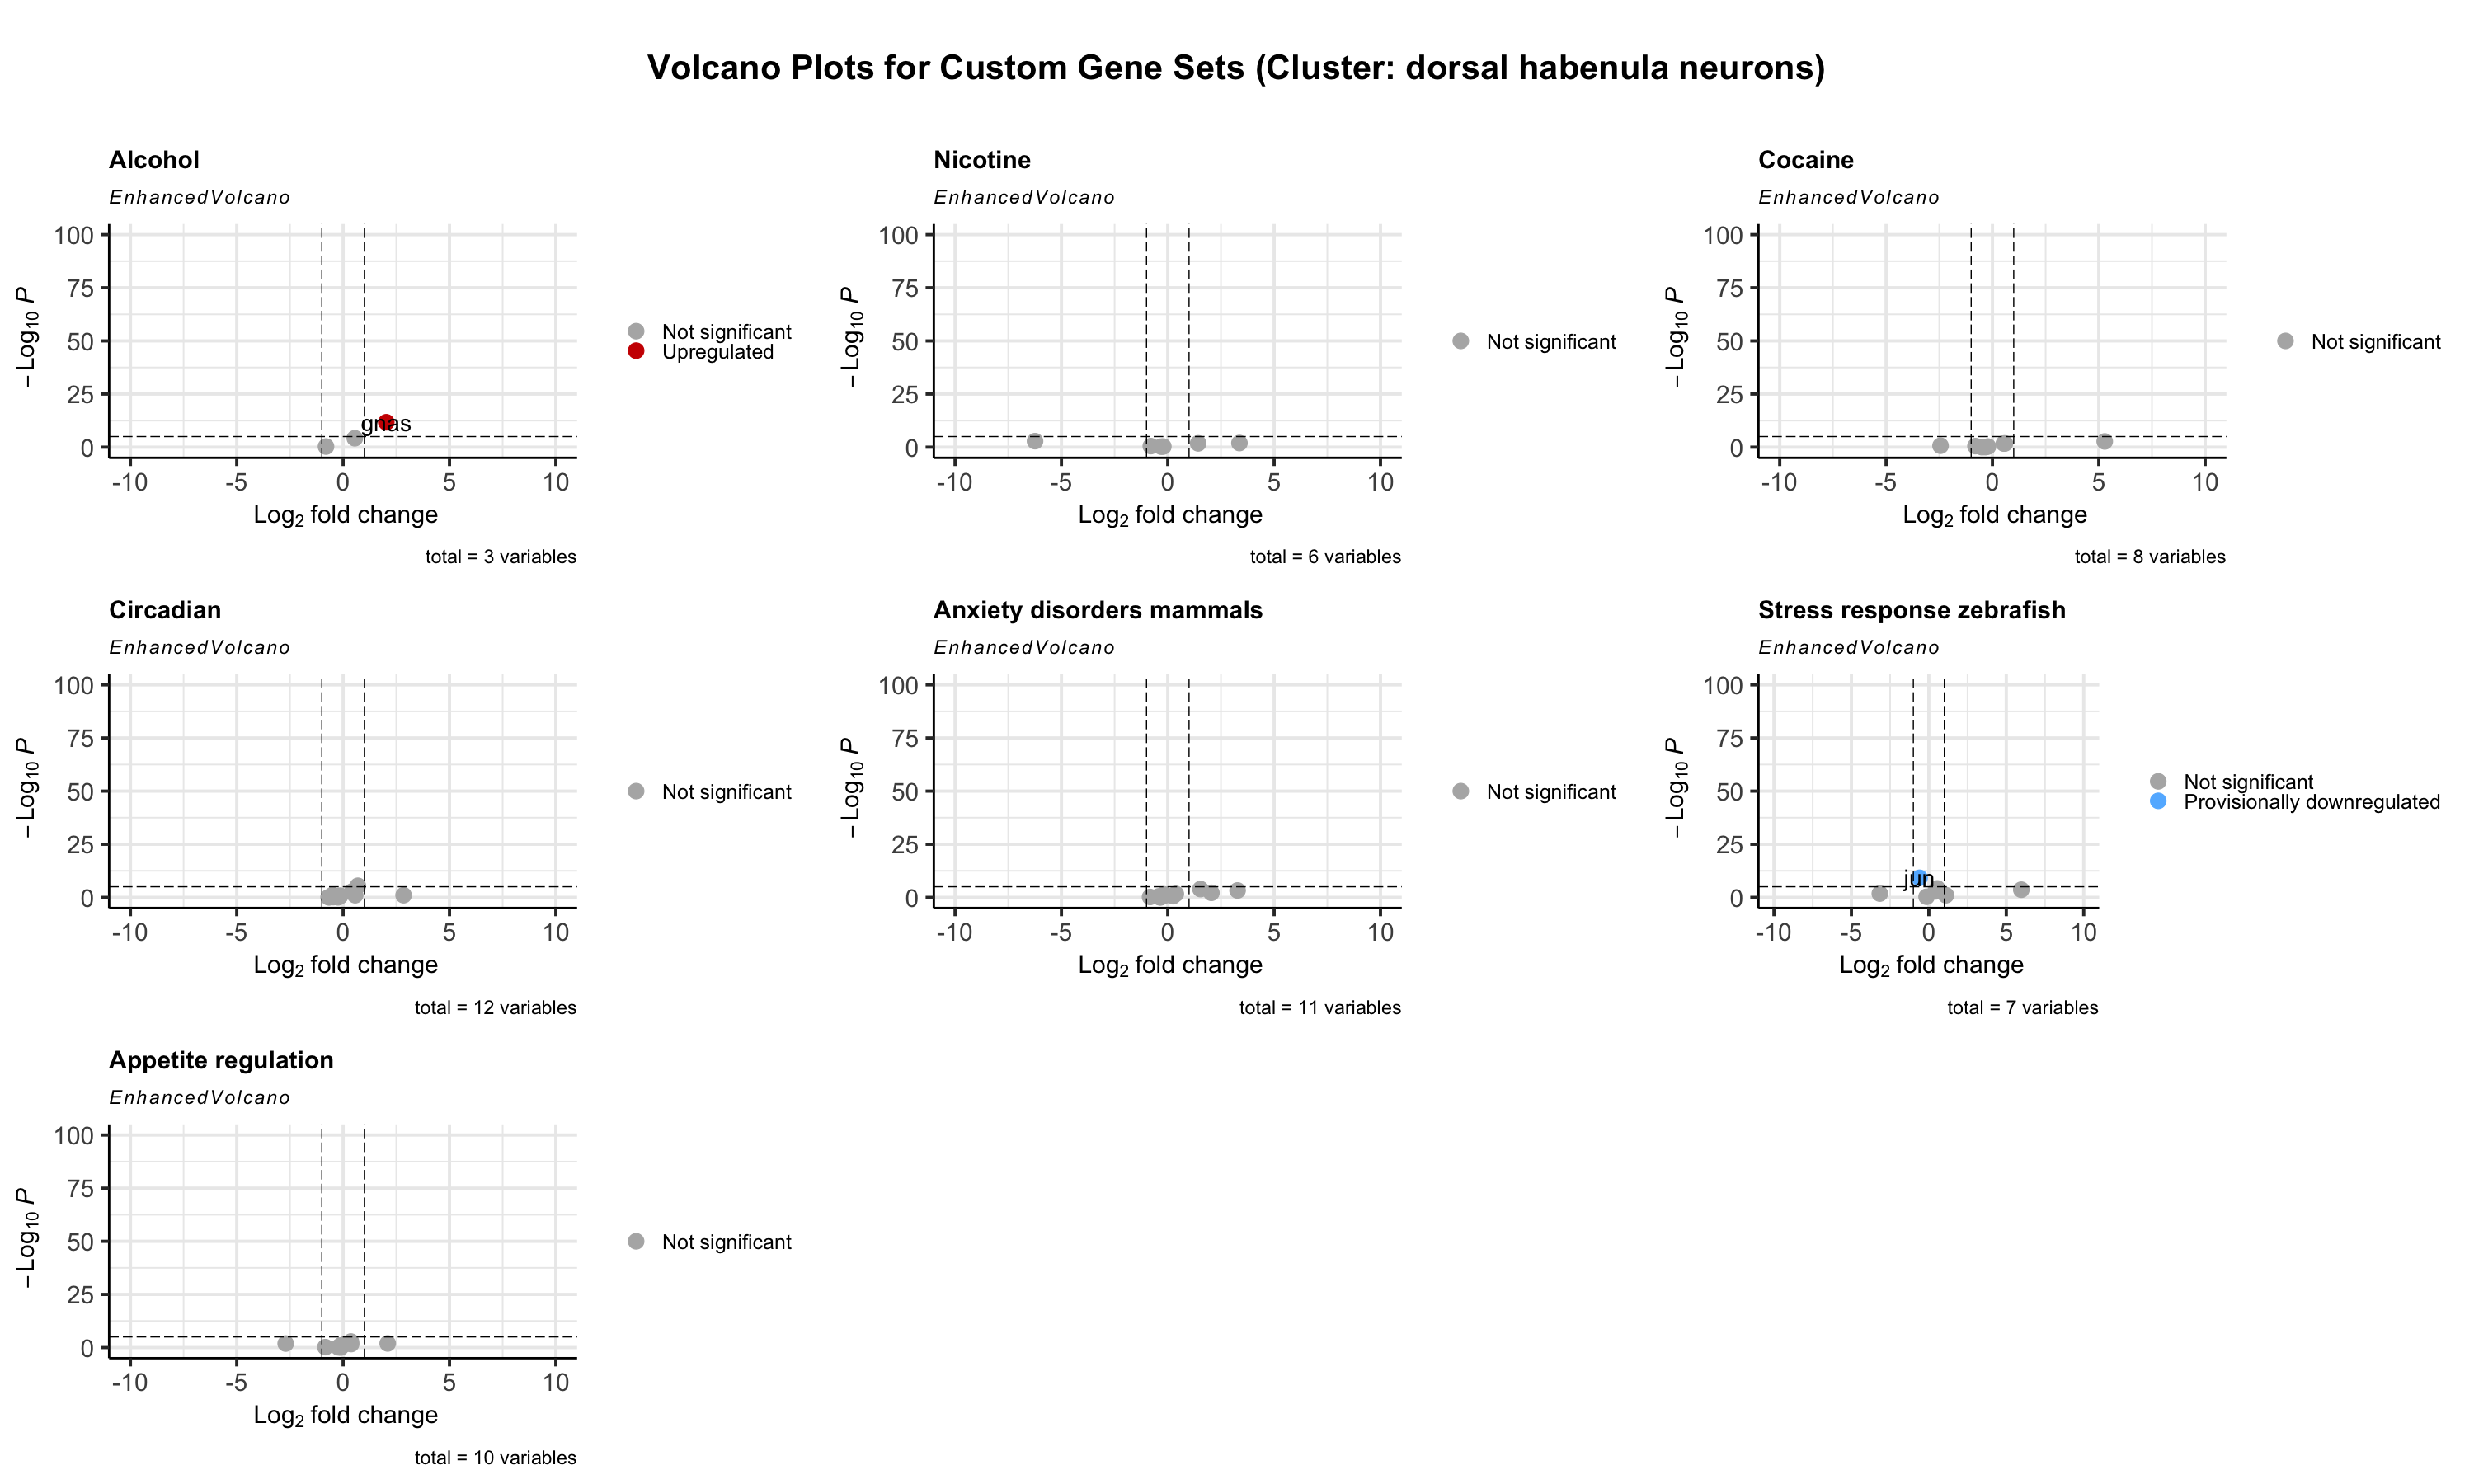

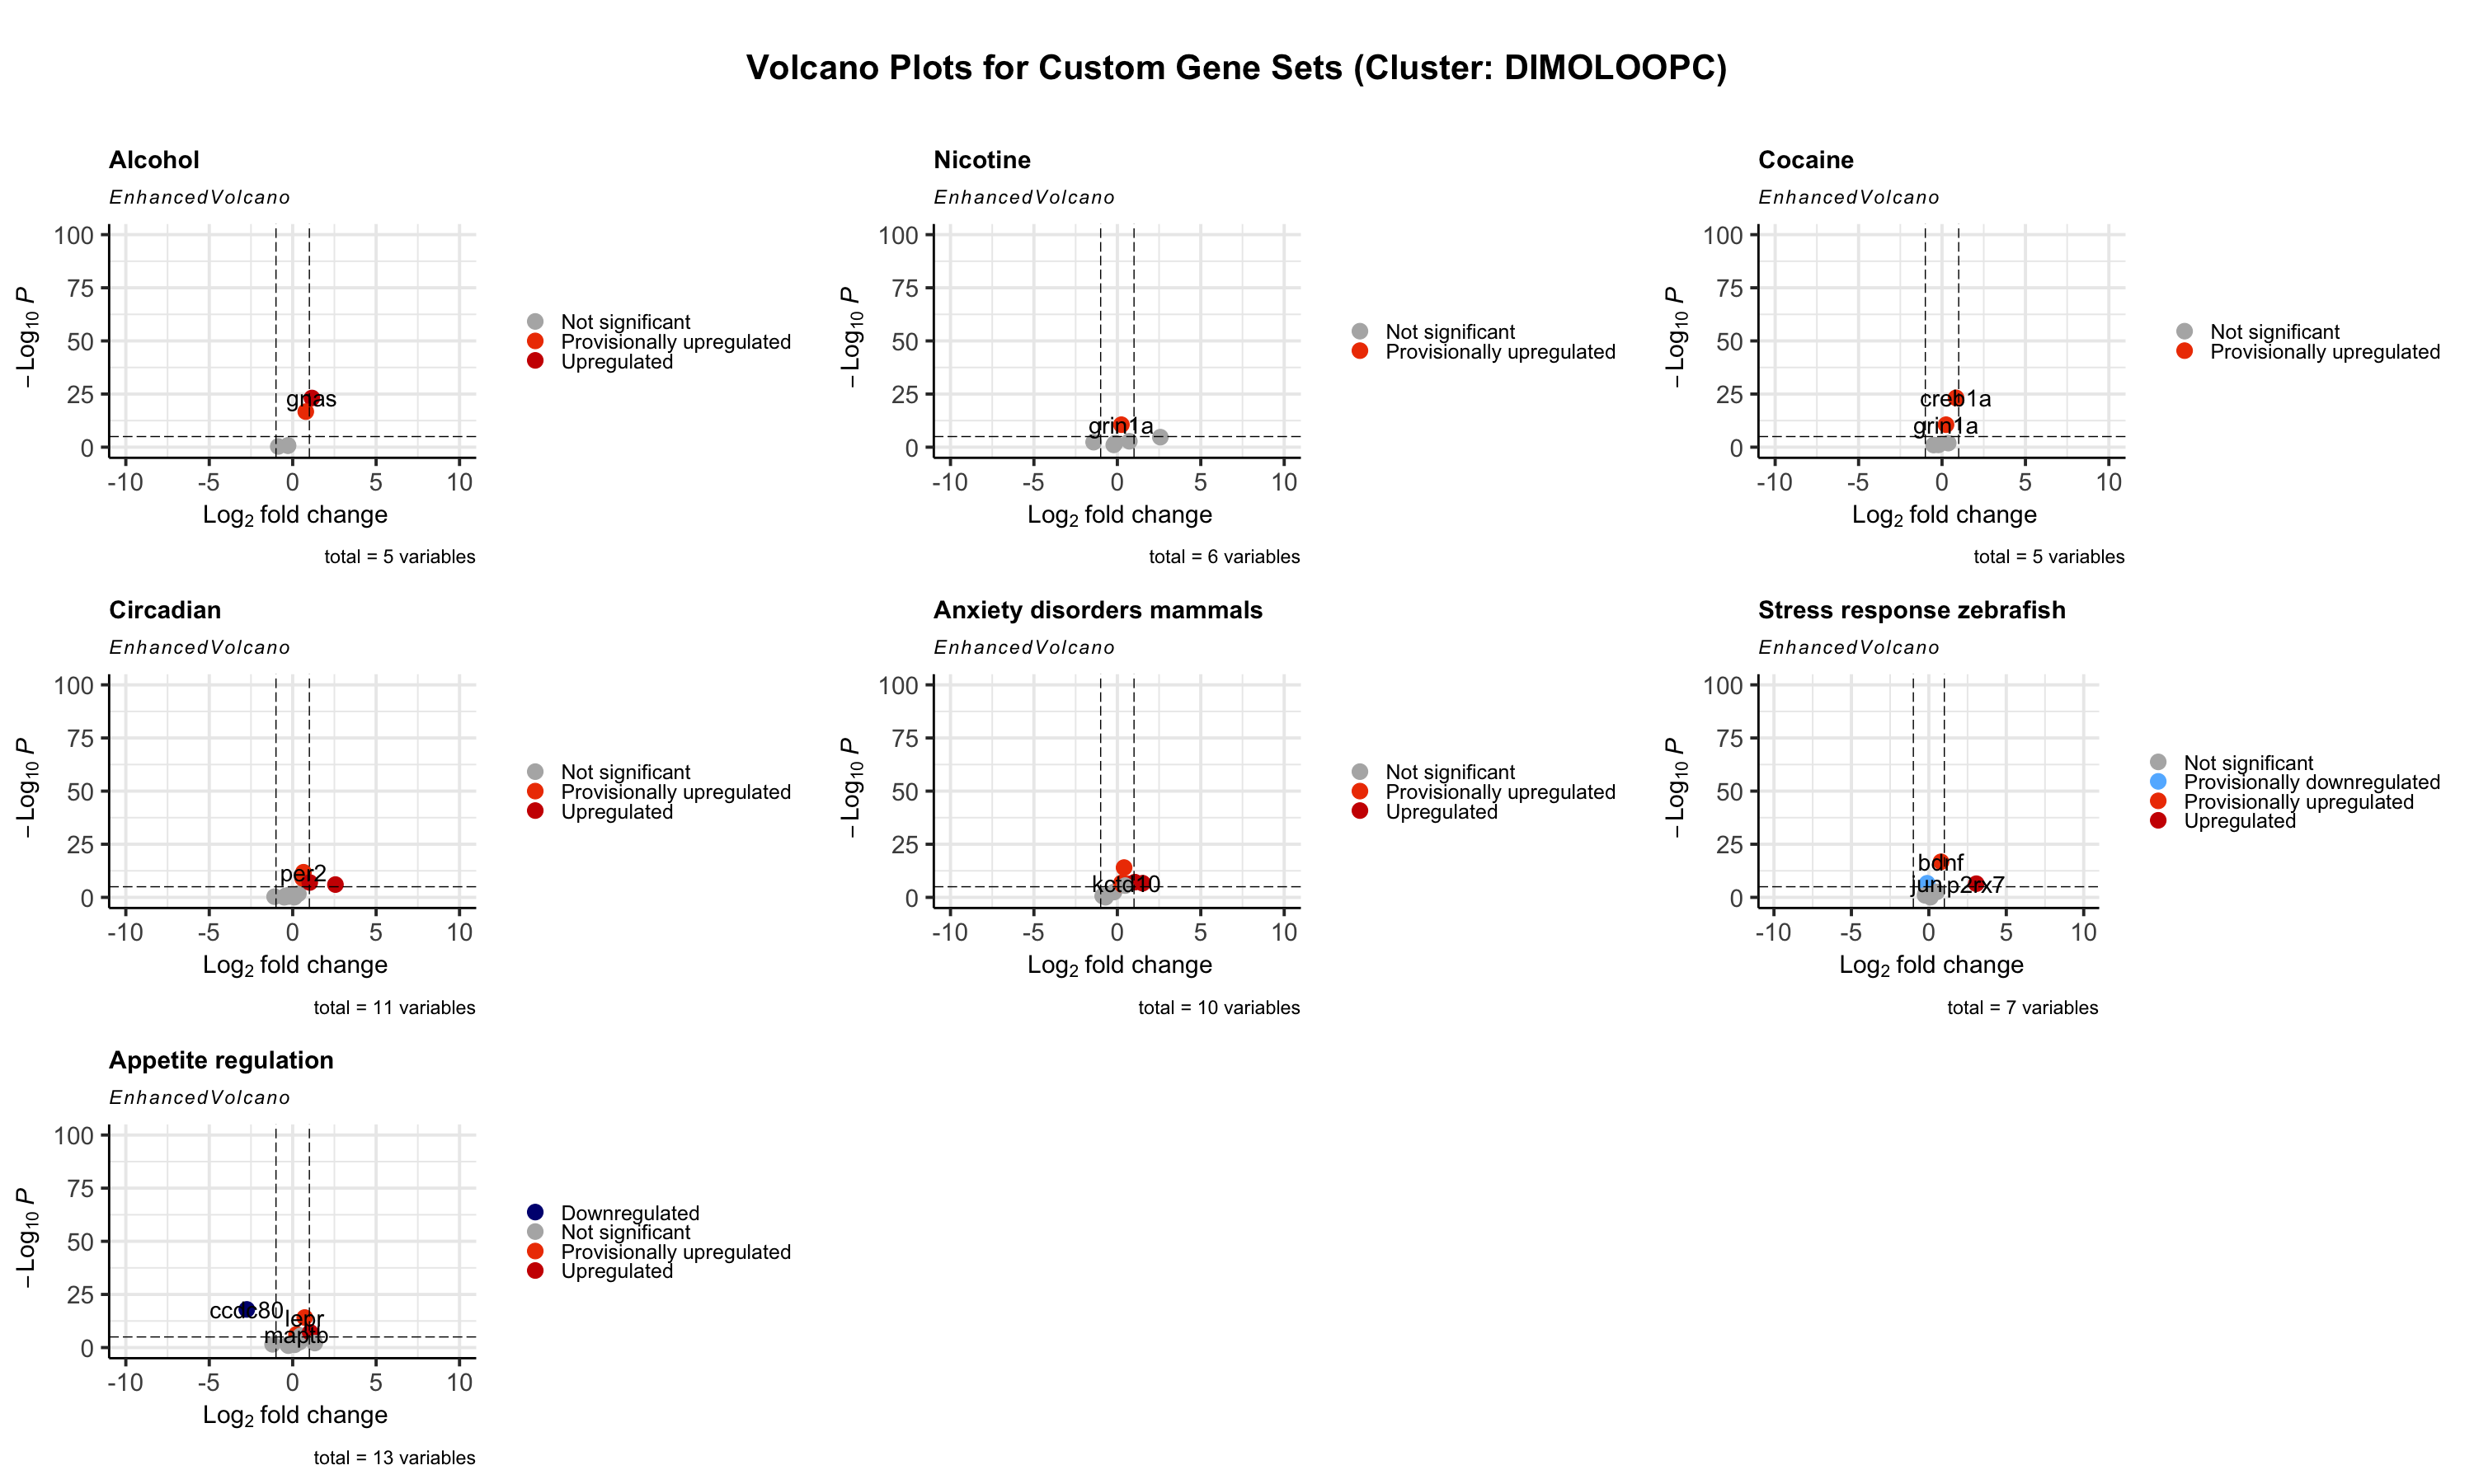

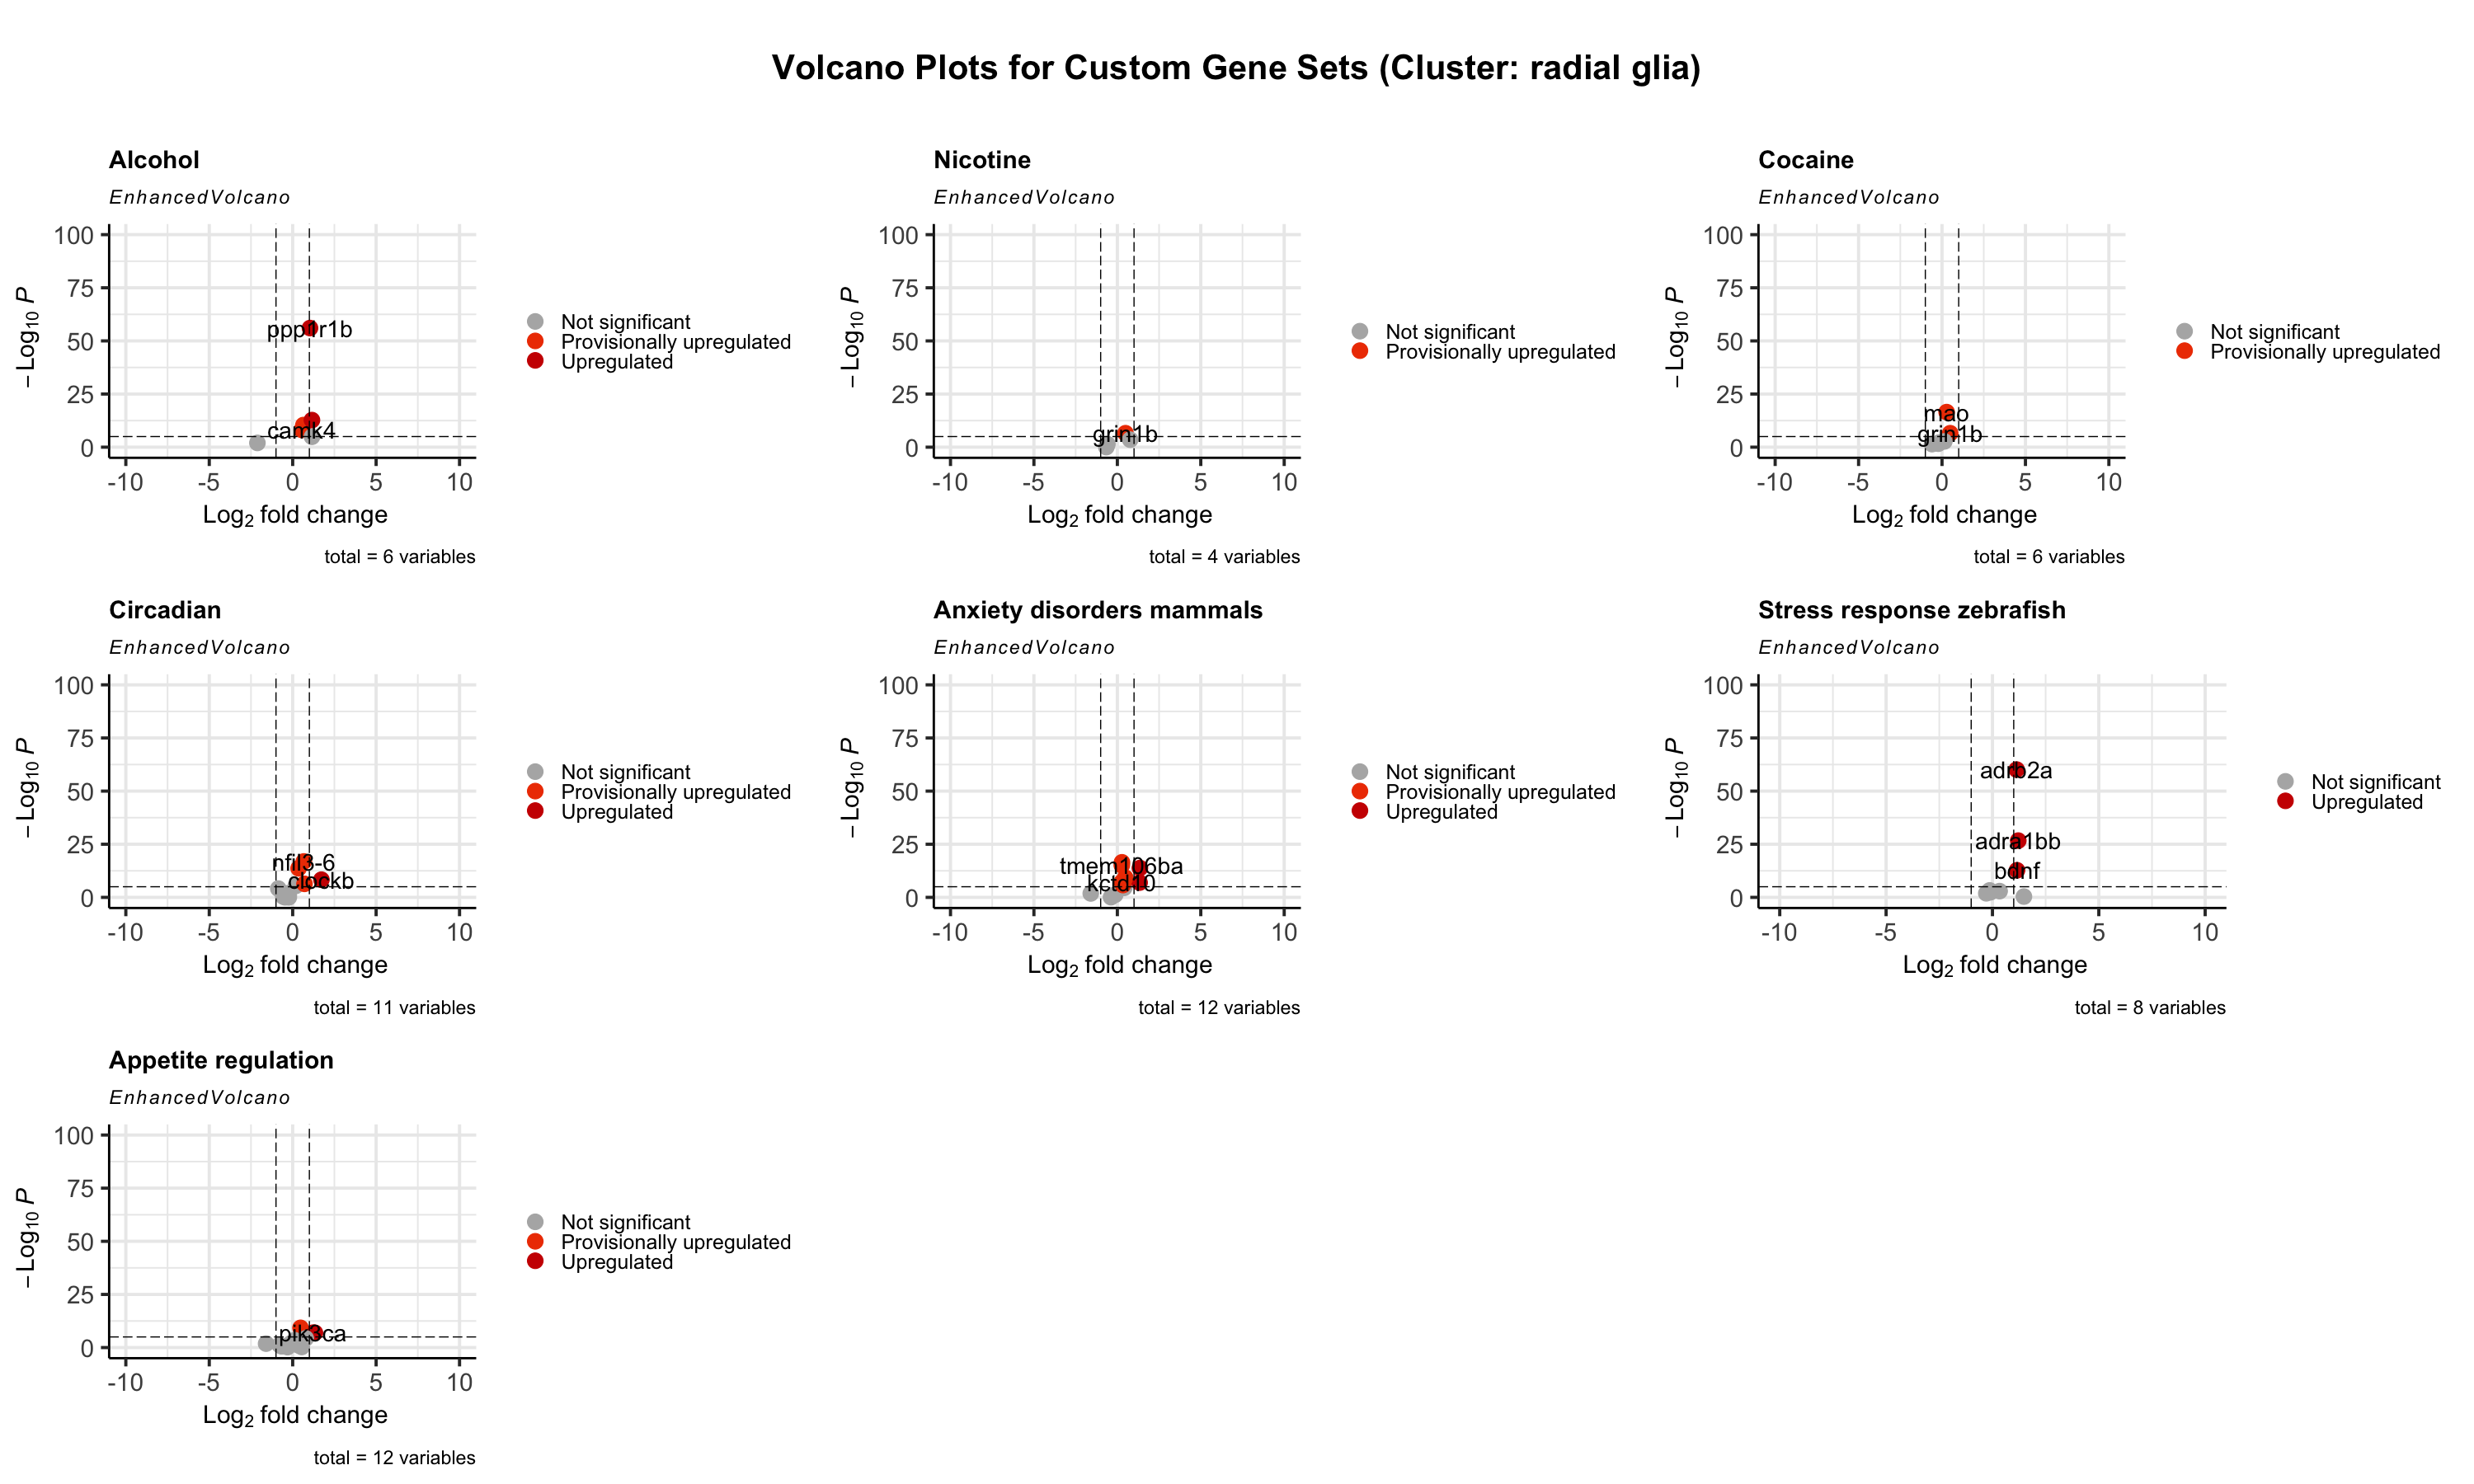

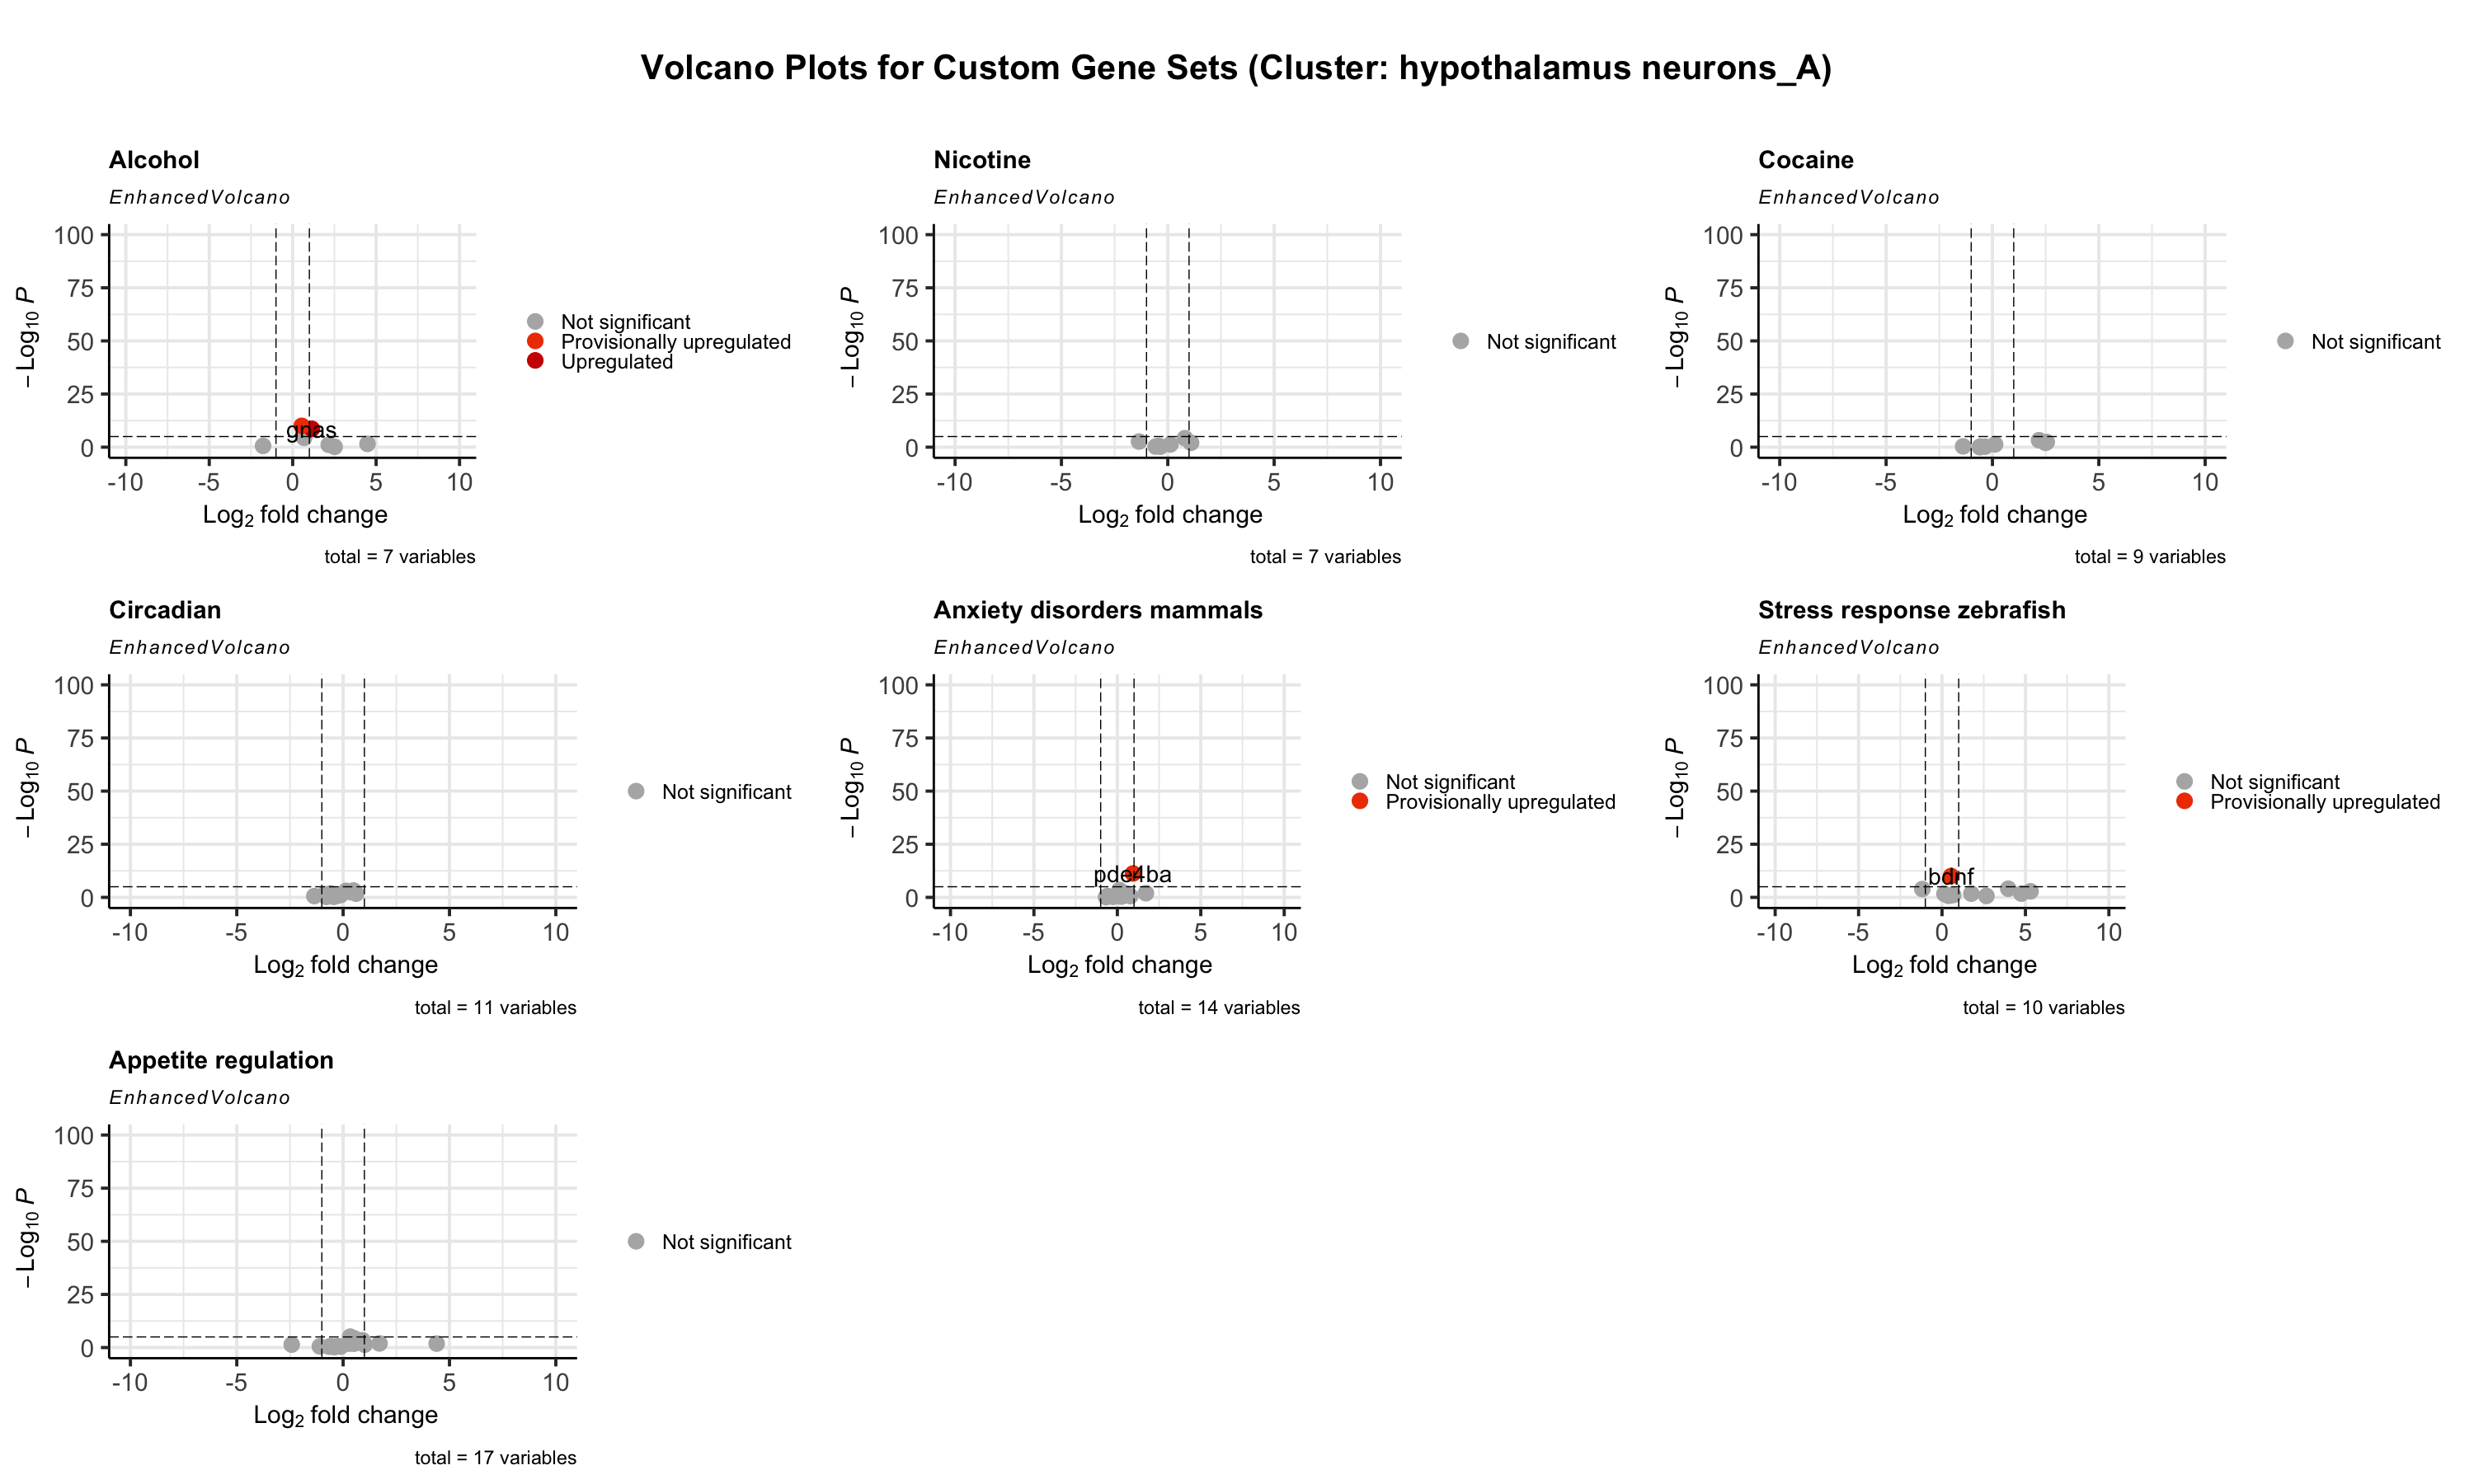

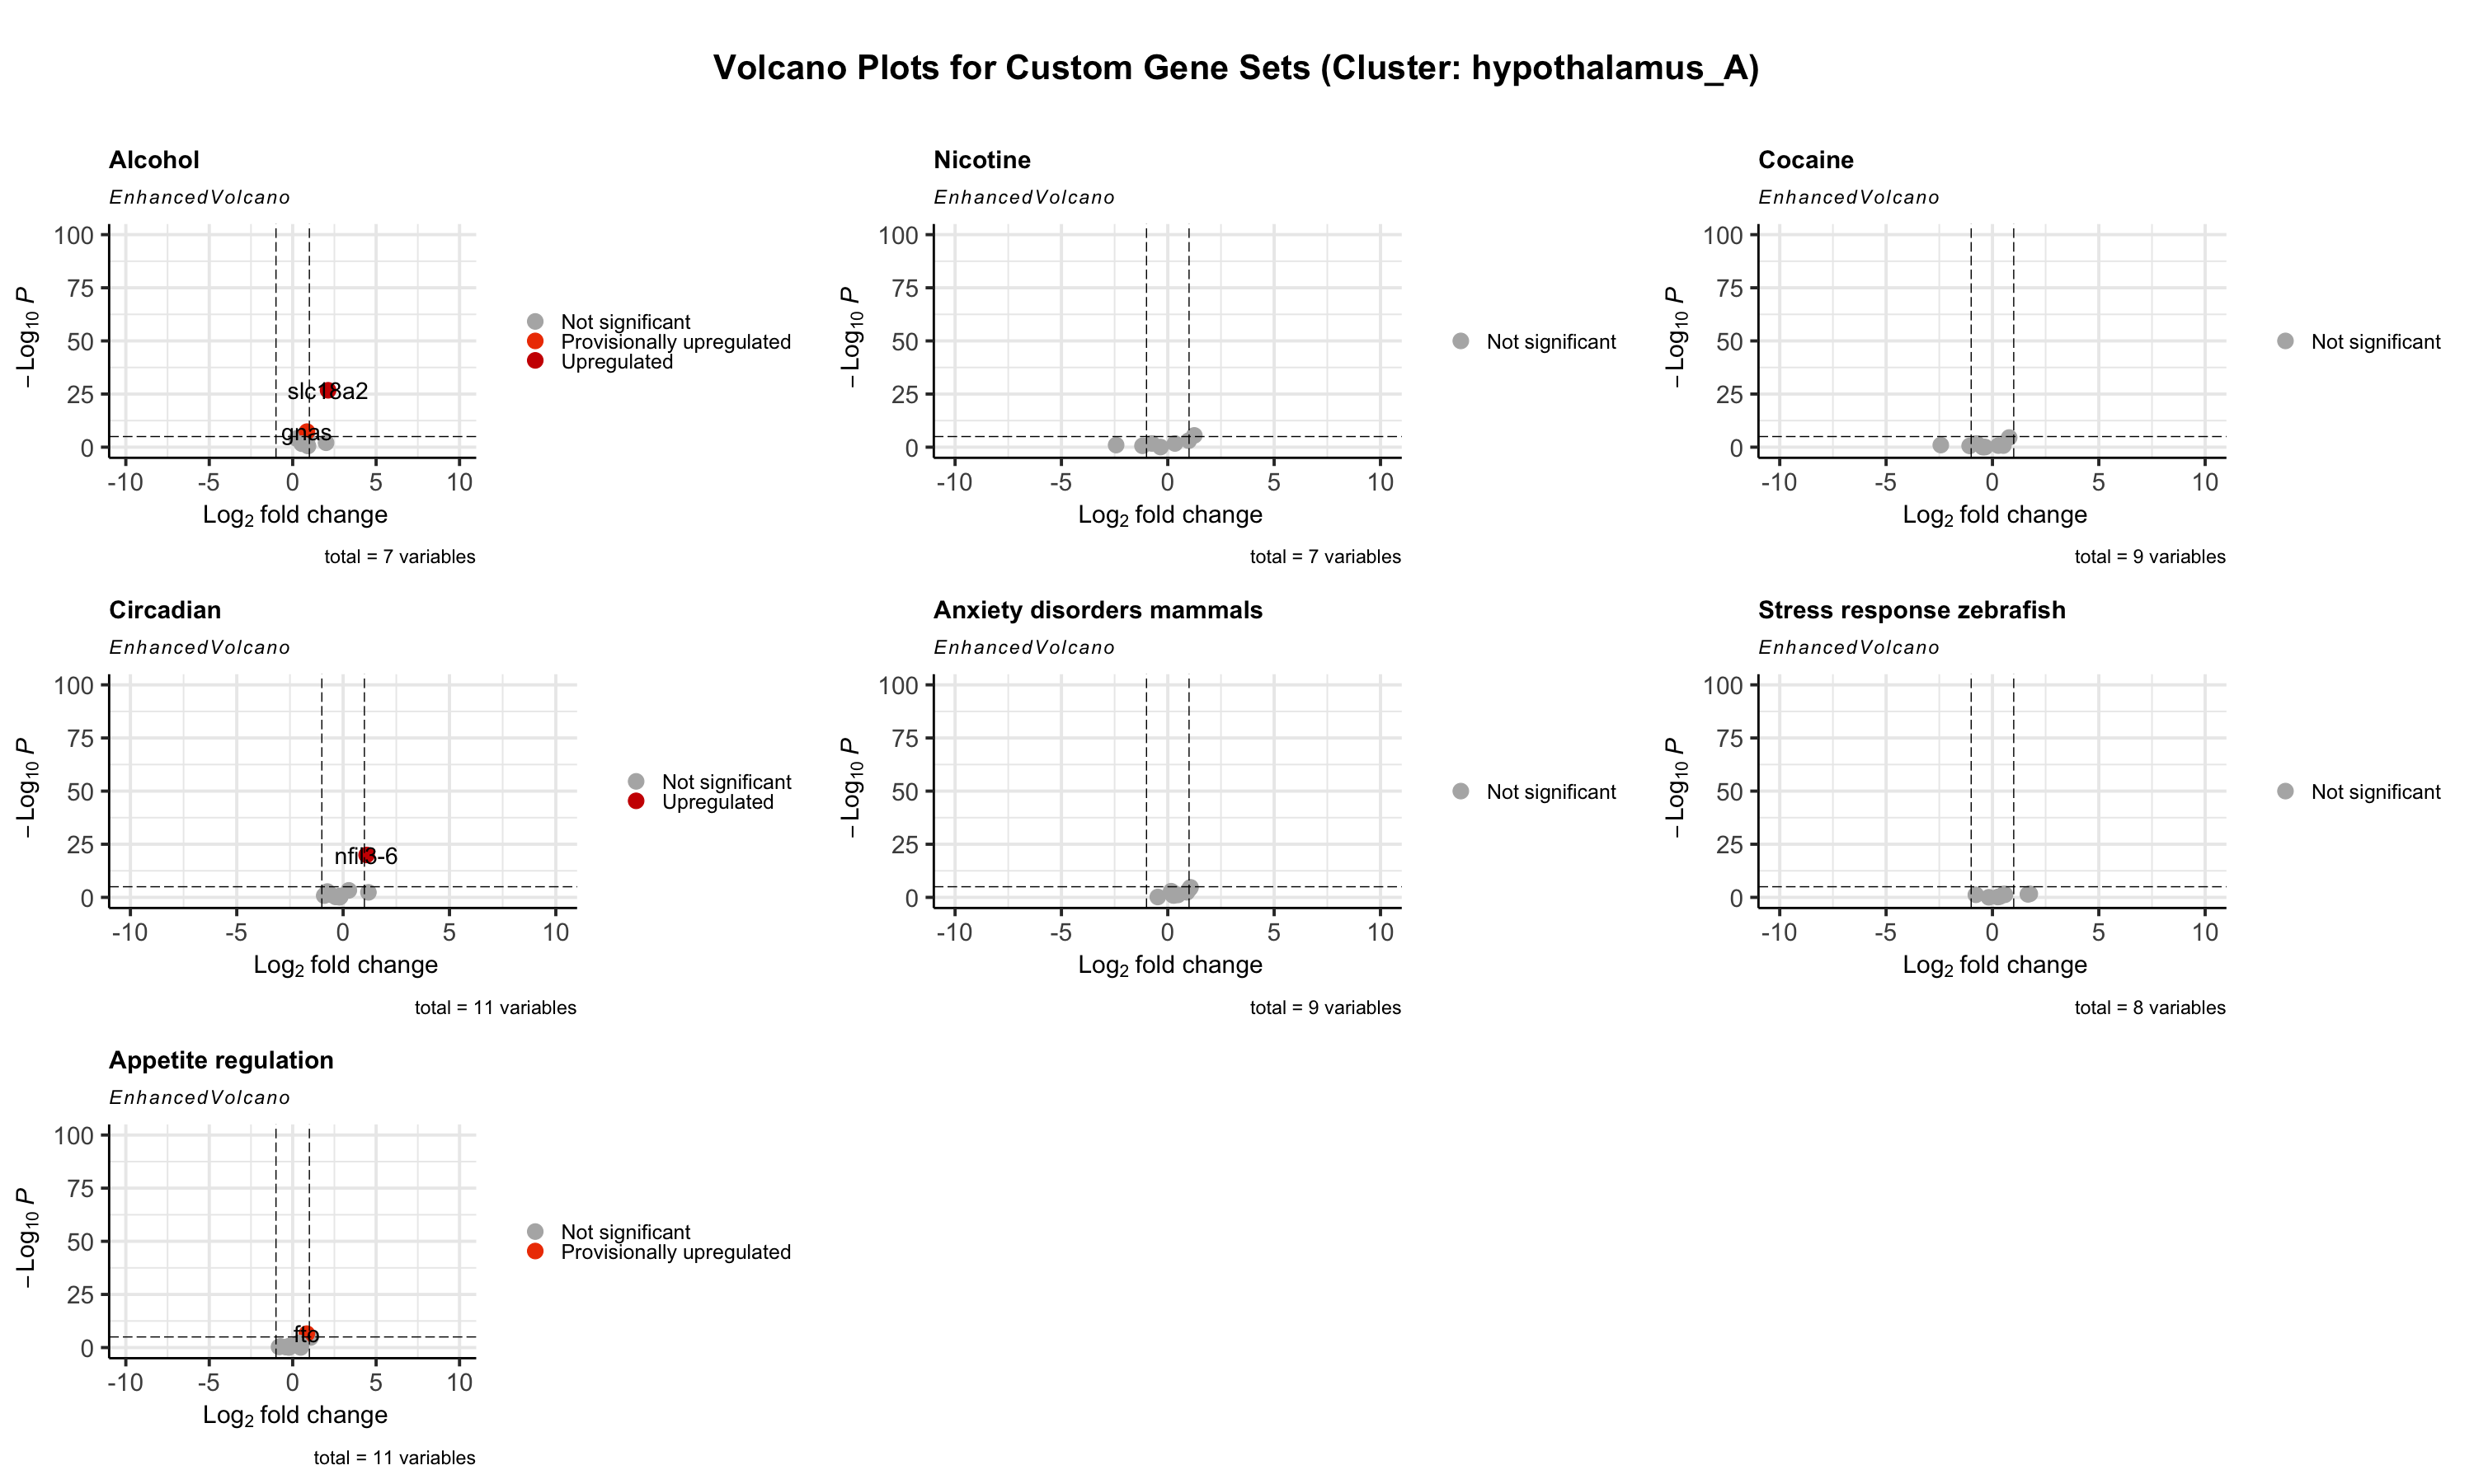

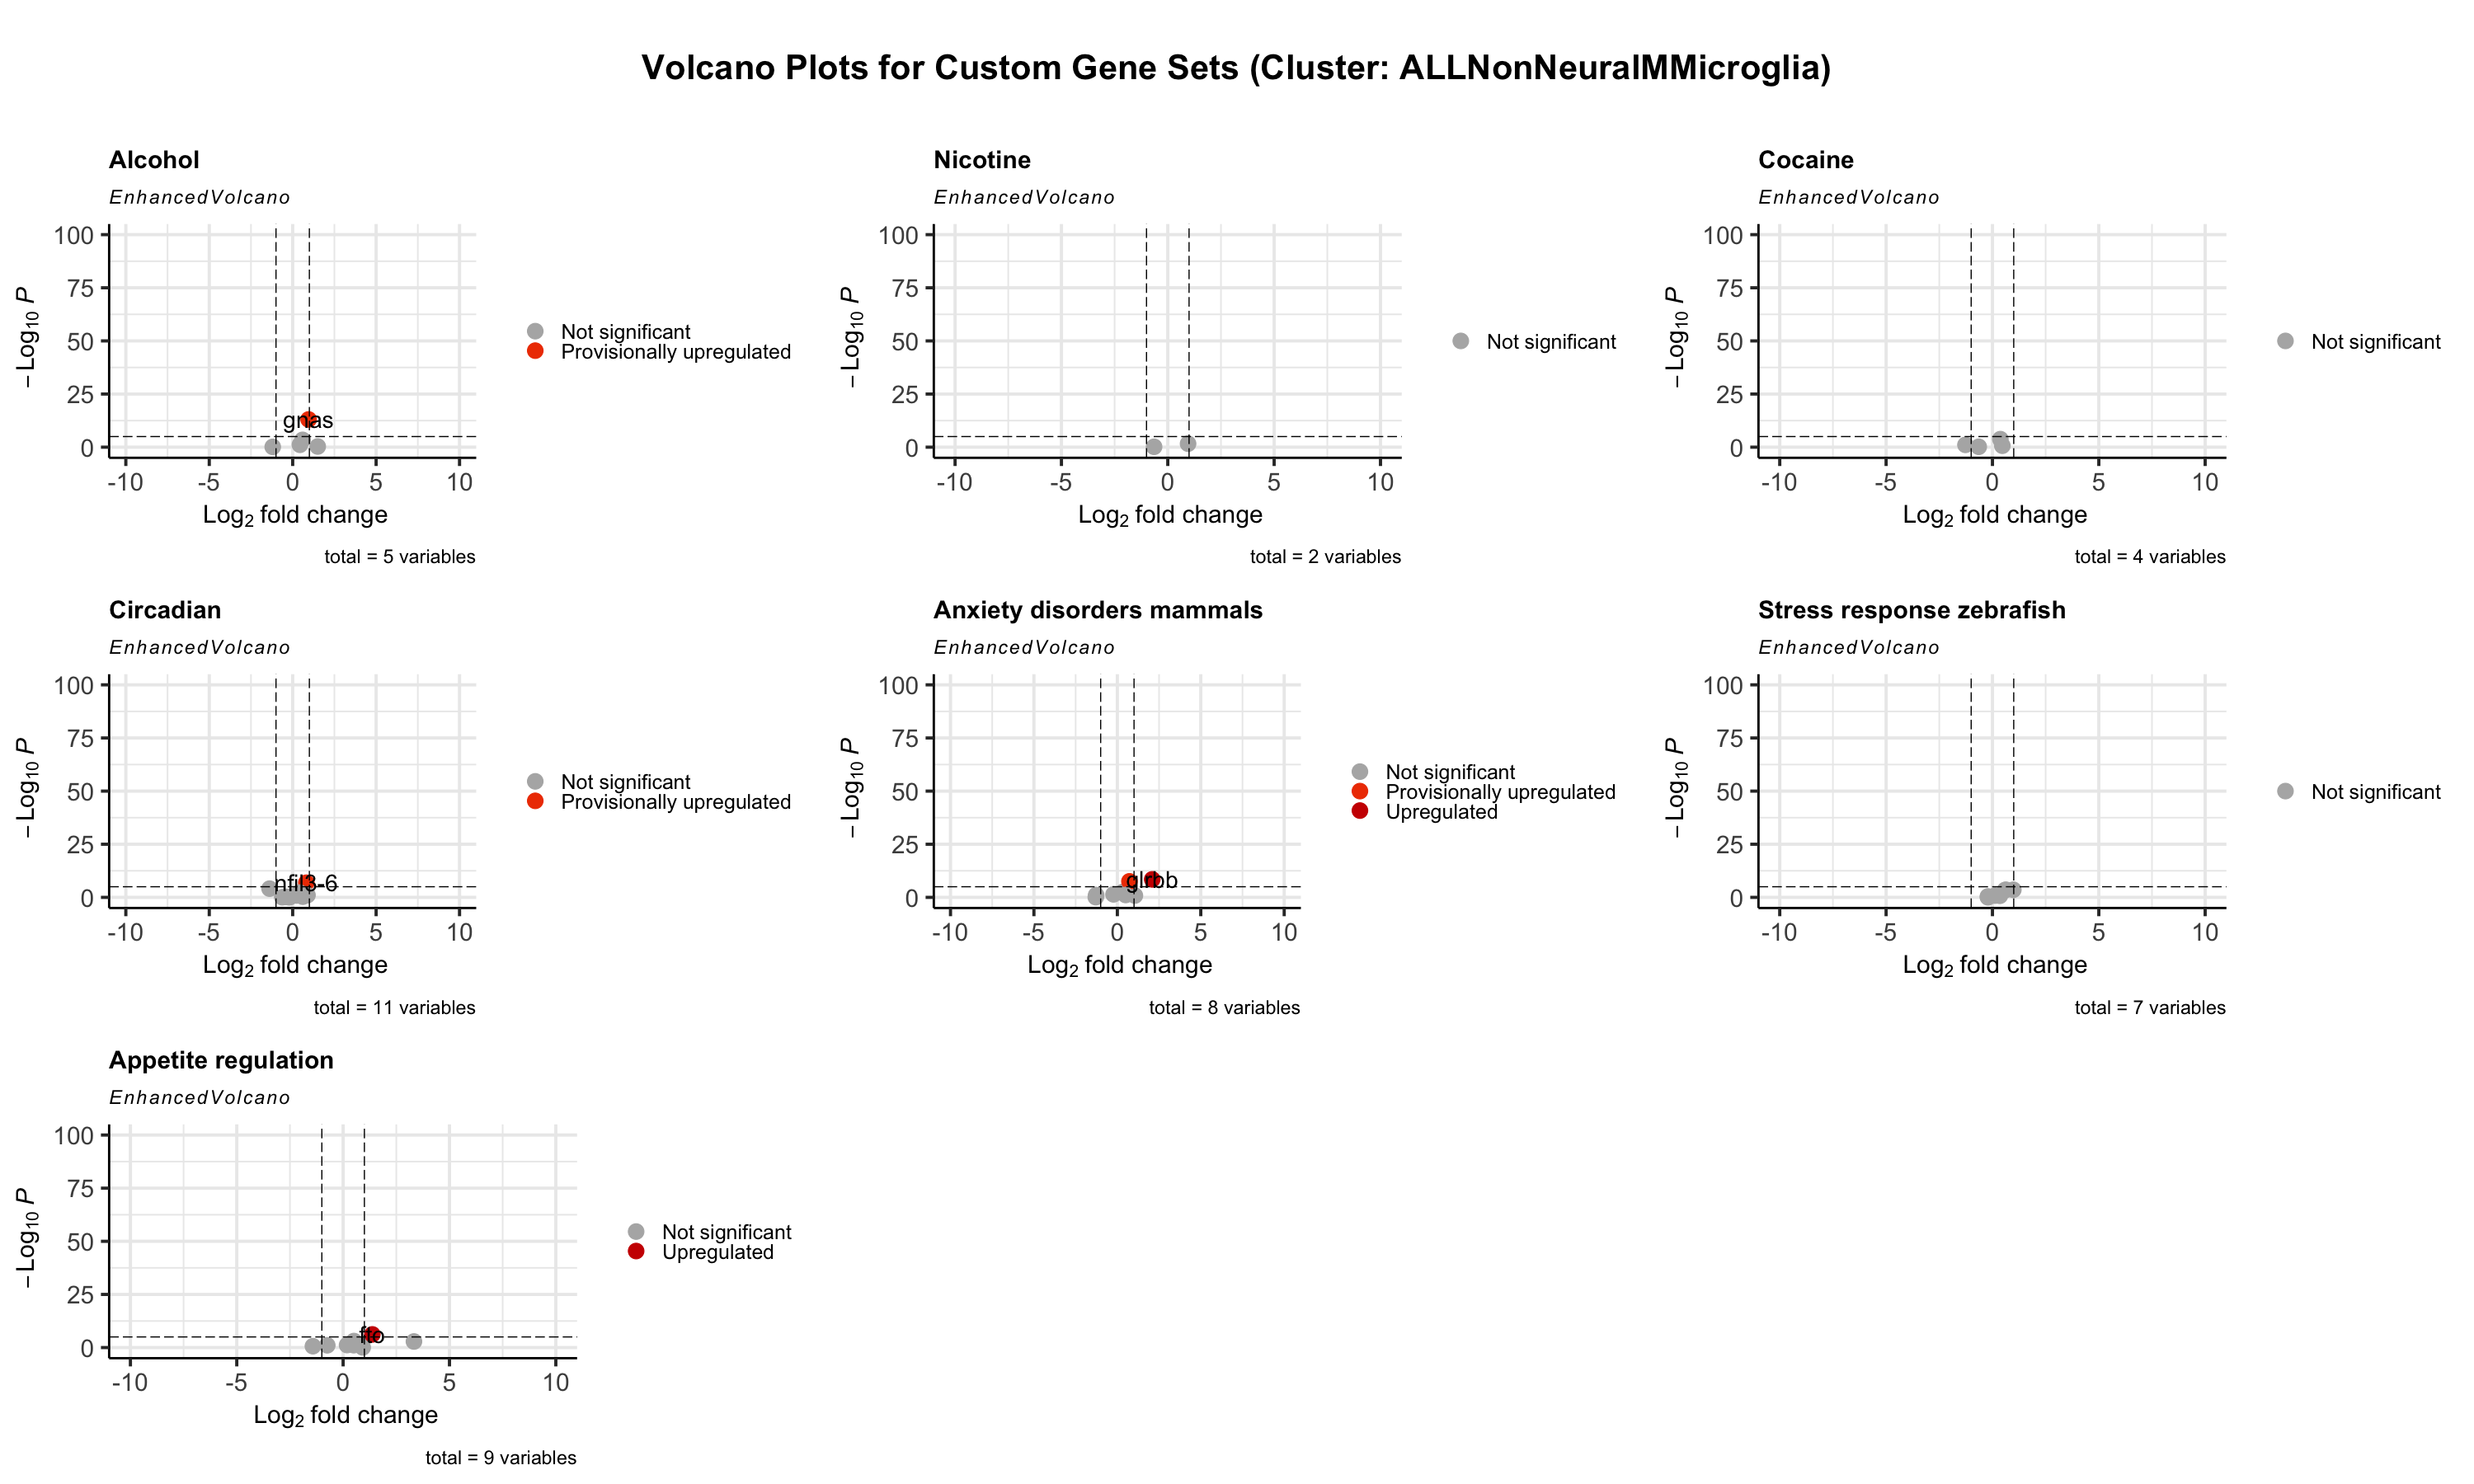

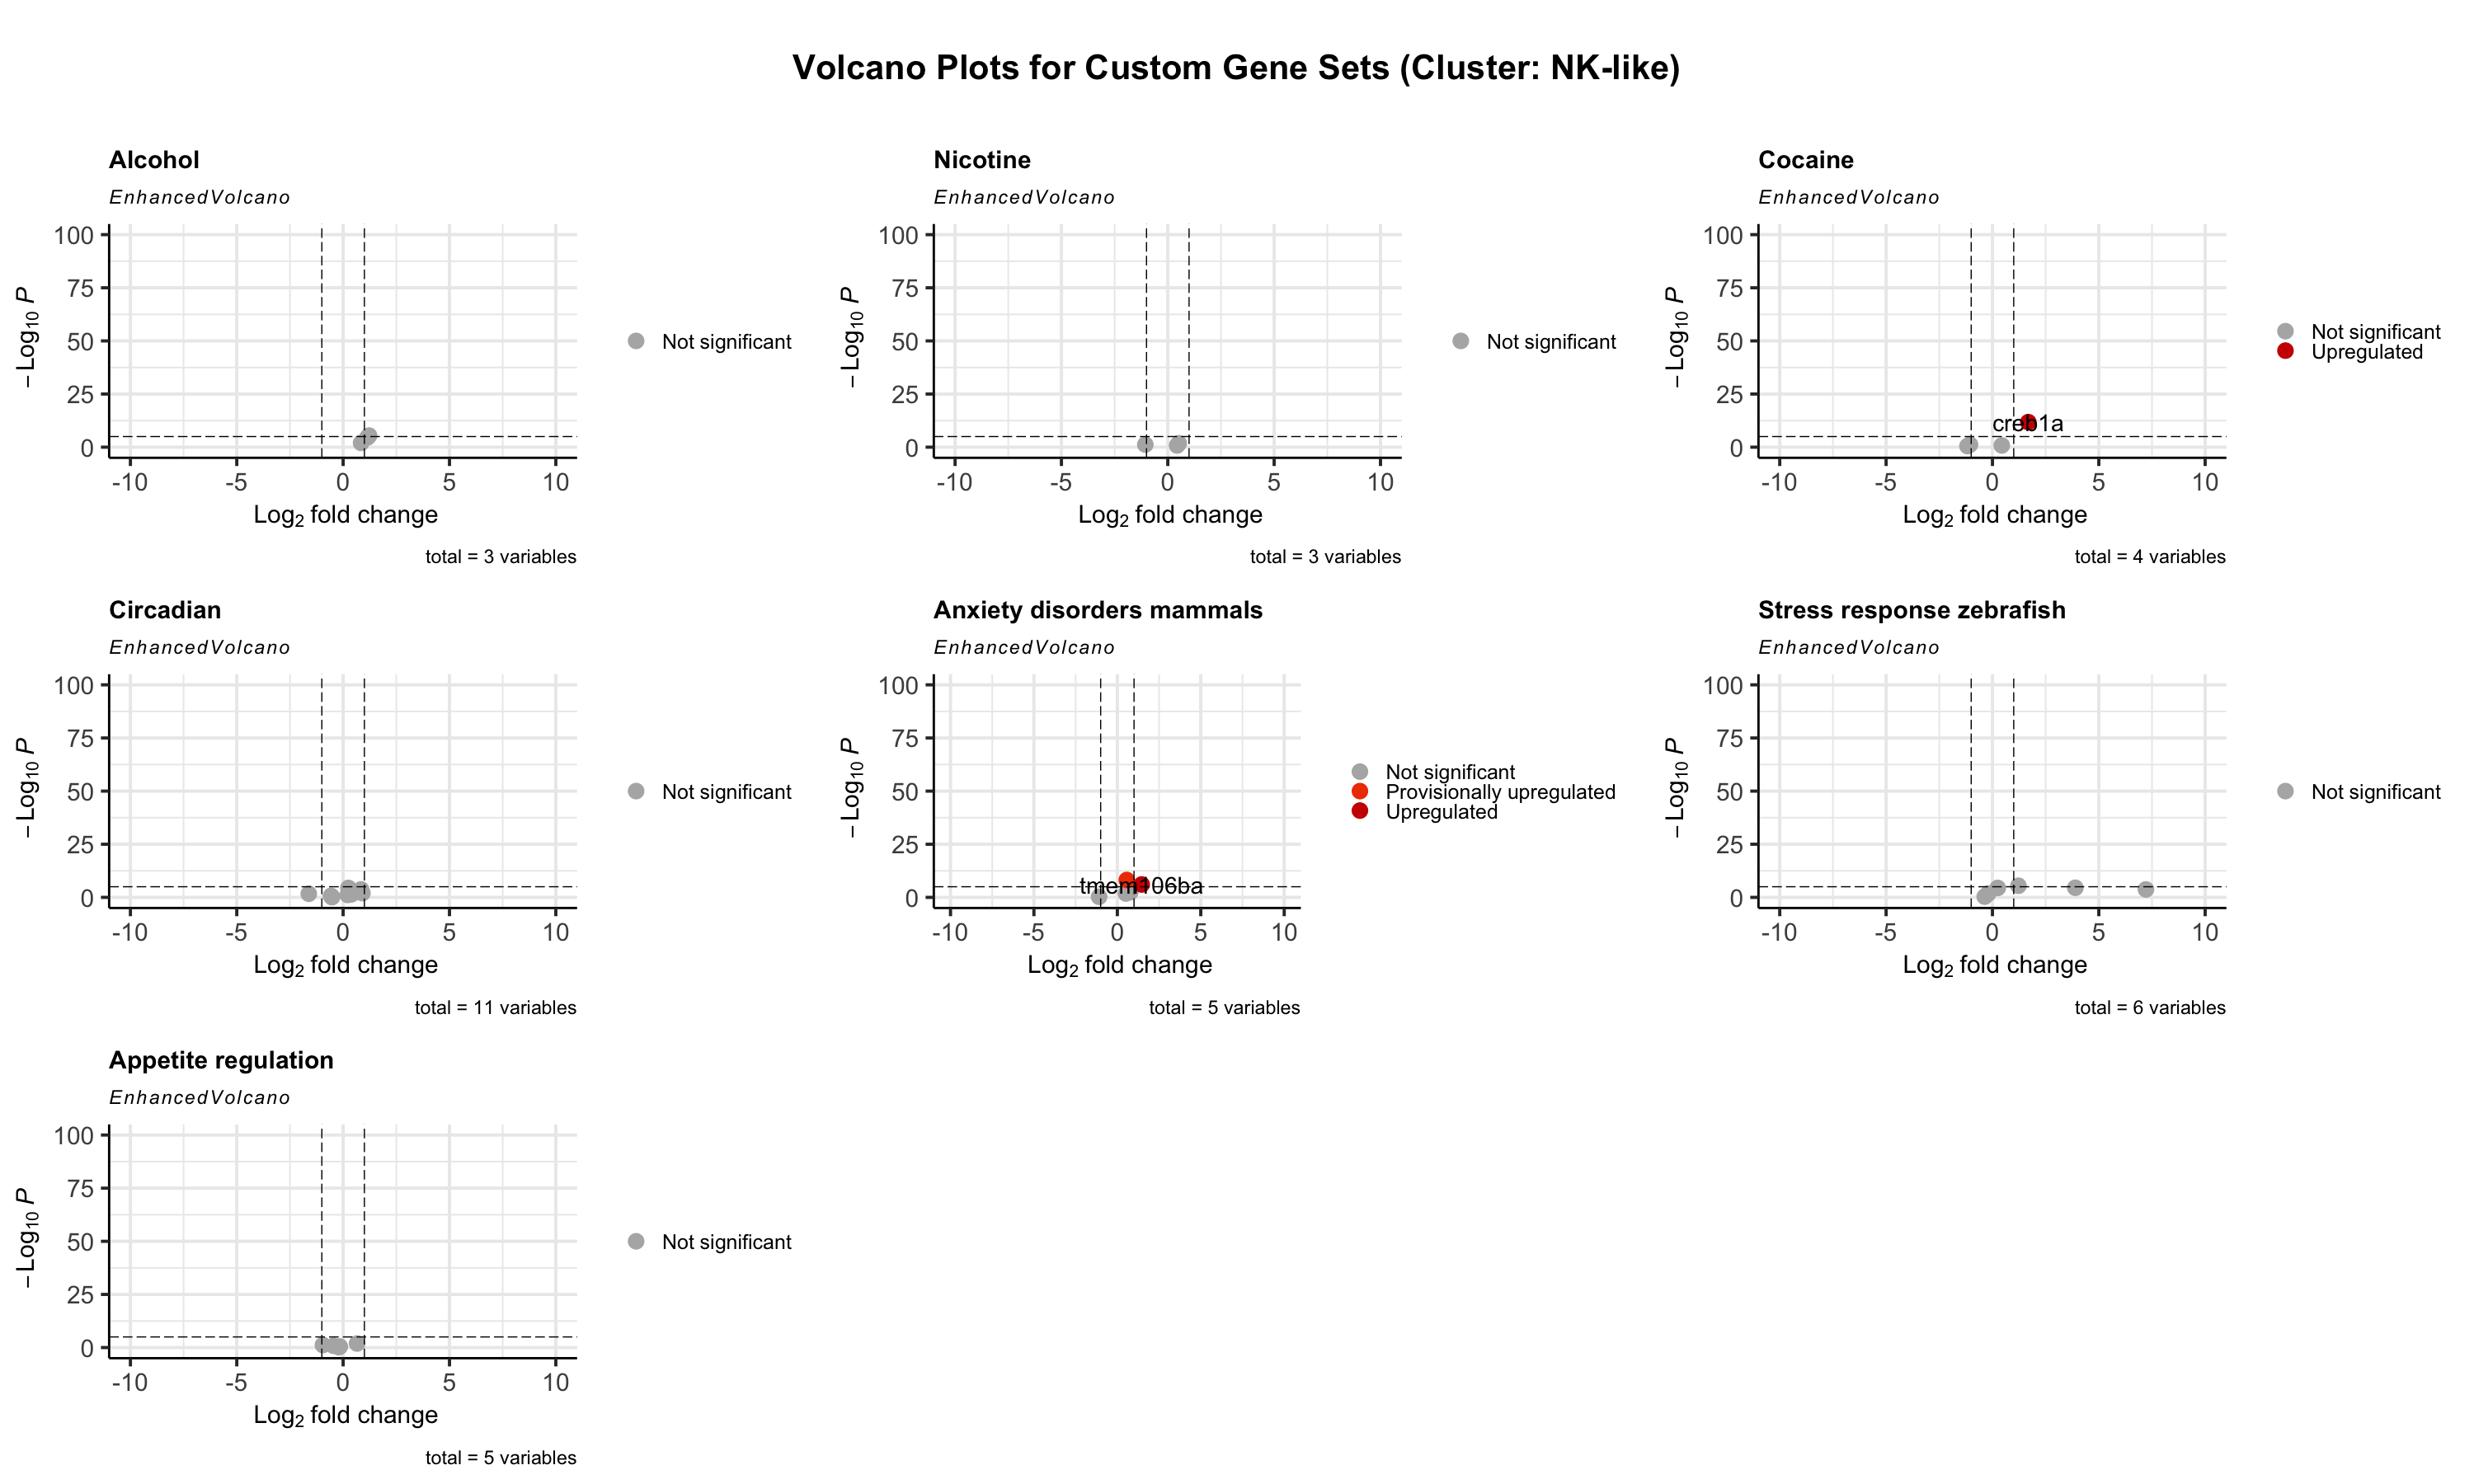

In [52]:
options(repr.plot.height = 15, repr.plot.width = 25)

# Gene-set volcano grids, per cluster
for (cluster in names(all_volcano_plots2)) {
  vp2 = all_volcano_plots2[[cluster]]

  if (length(vp2) == 0) {
    next
  }

  grid.arrange(
    grobs = vp2,
    ncol = 3,
    top = textGrob(
      paste0("\nVolcano Plots for Custom Gene Sets (Cluster: ", cluster, ")\n"),
      gp = gpar(fontsize = 25, fontface = "bold")
    )
  )
}